In [1]:
import setup
from importlib import reload
reload(setup)
from setup import *

# 1D Fickian diffusion 
henry_constant = 1e-3 * 1000 # mol/m^3/atm for CO in water at 293.15K 
diffusion_coefficient = 1.91e-9 # m2/s for CO in water at 293.15K 
A_site = F * 1e-4 / (210e-6 * N_A) # Surface area of a single Pt site: 1cm2 = 210uC (HUPD)
delta_BL_micron = 1e-6 # Setting the denominator to 1 micron to allow for delta_BL to be in microns
k1_fick = diffusion_coefficient * henry_constant * N_A * A_site / delta_BL_micron
log_k1_fick = np.log(k1_fick)

# ER 2 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.45,15
,3000,0,0.43,11
,3000,0,0.45,15
,3000,0,0.44,15


Computed from 4000 posterior samples and 2324 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  4568.99    64.85
p_loo       12.50        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2324  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



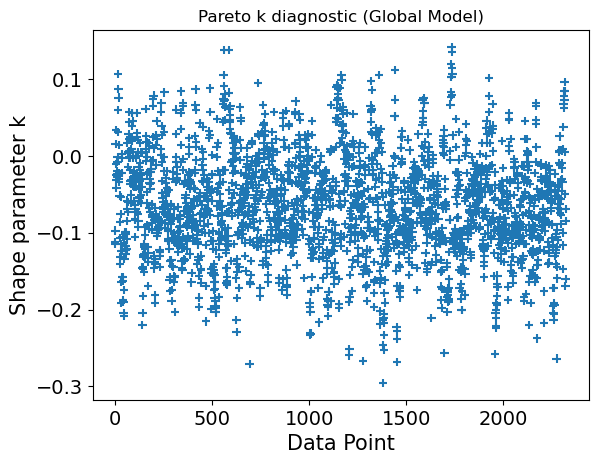

In [2]:
with pm.Model() as ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + np.log(C_KOH_in)
    rate = observables(log_rate) 

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.108  0.001  -0.110   -0.105      0.000    0.000    3171.0    2983.0    1.0
deltaG4_0   0.048  0.006   0.038    0.058      0.000    0.000    2388.0    2746.0    1.0
Gact2_0     0.752  0.000   0.751    0.752      0.000    0.000    2906.0    2620.0    1.0
beta_2      0.255  0.003   0.249    0.261      0.000    0.000    2671.0    2919.0    1.0
sigma_rel   0.199  0.011   0.179    0.220      0.000    0.000    1907.0    1824.0    1.0
sigma_base  0.005  0.000   0.004    0.006      0.000    0.000    3192.0    2693.0    1.0
exponent    1.372  0.046   1.290    1.459      0.001    0.001    1822.0    1983.0    1.0


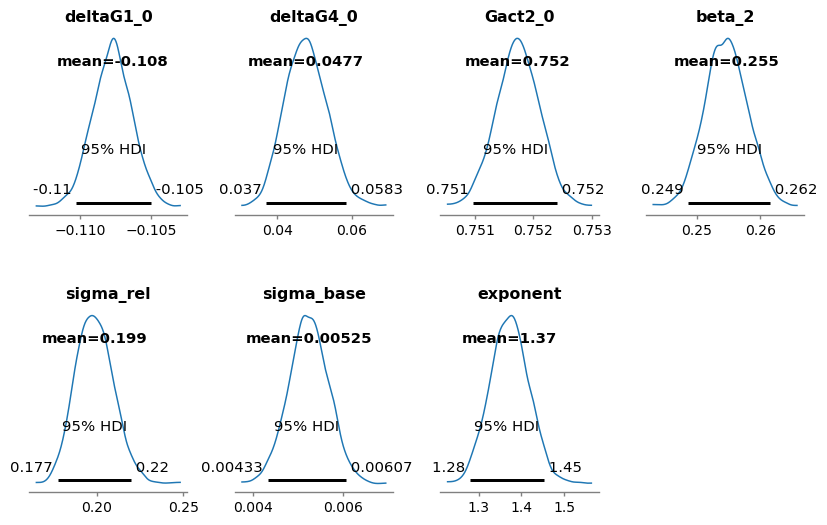

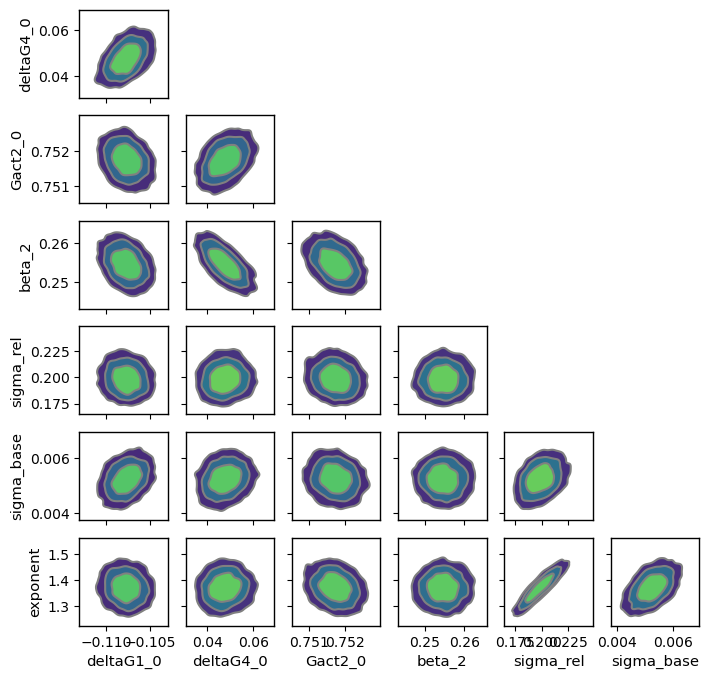

Sampling: [rate]


rate: 0.817


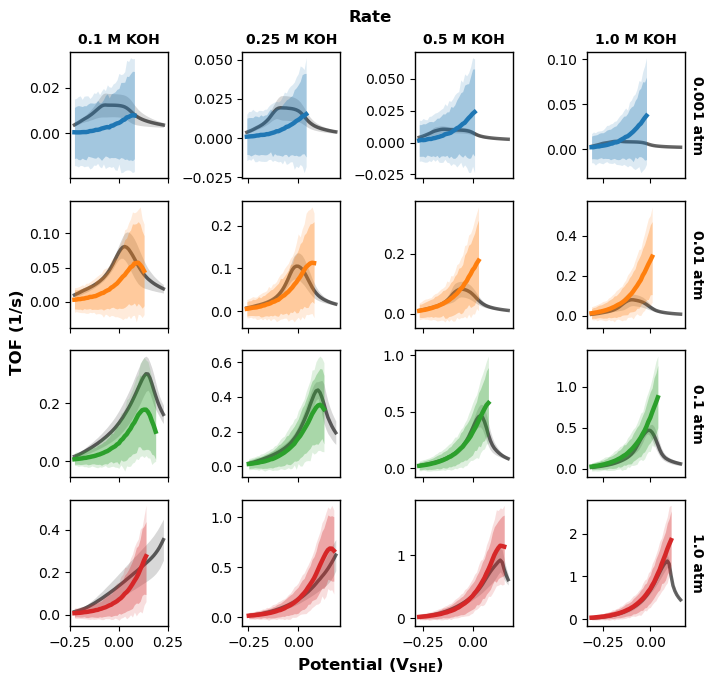

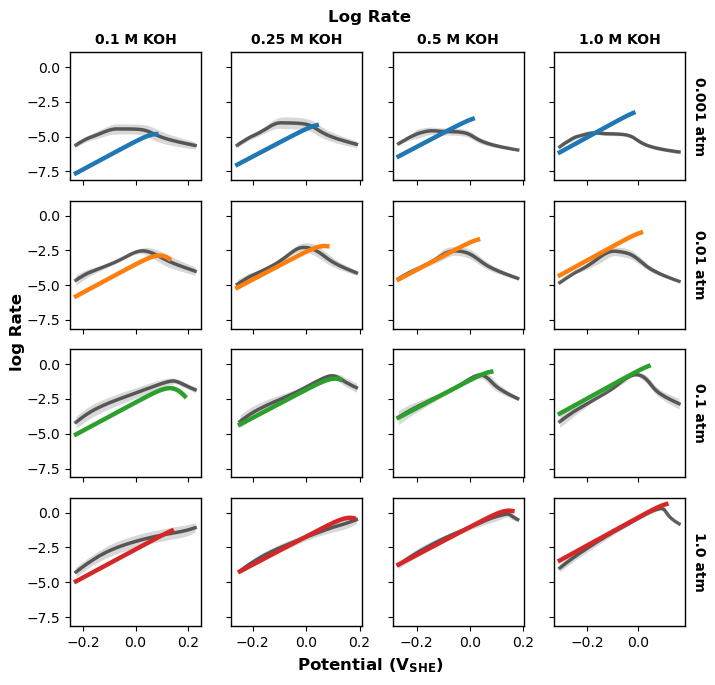

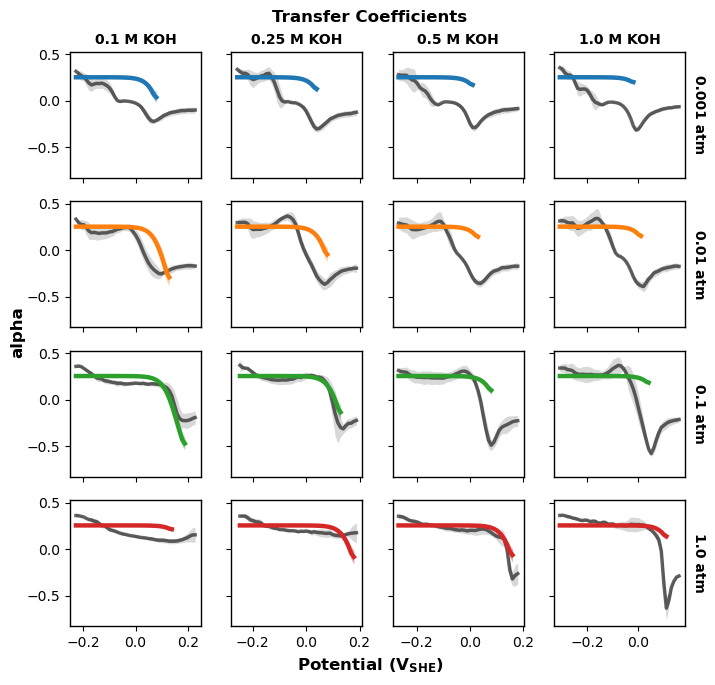

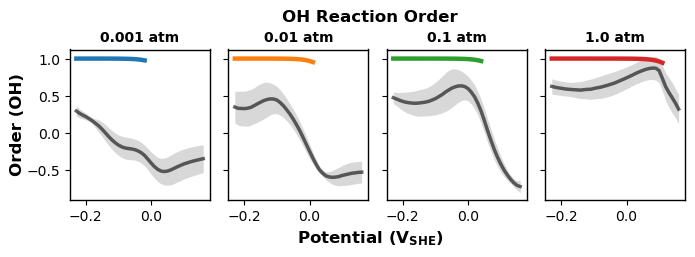

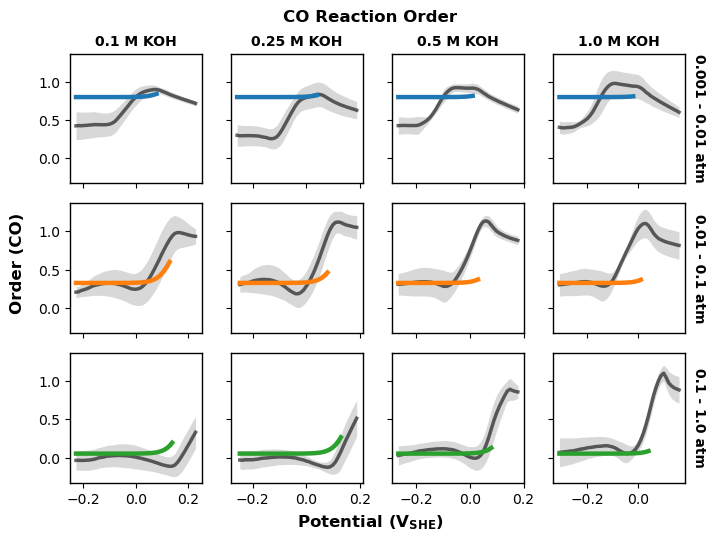

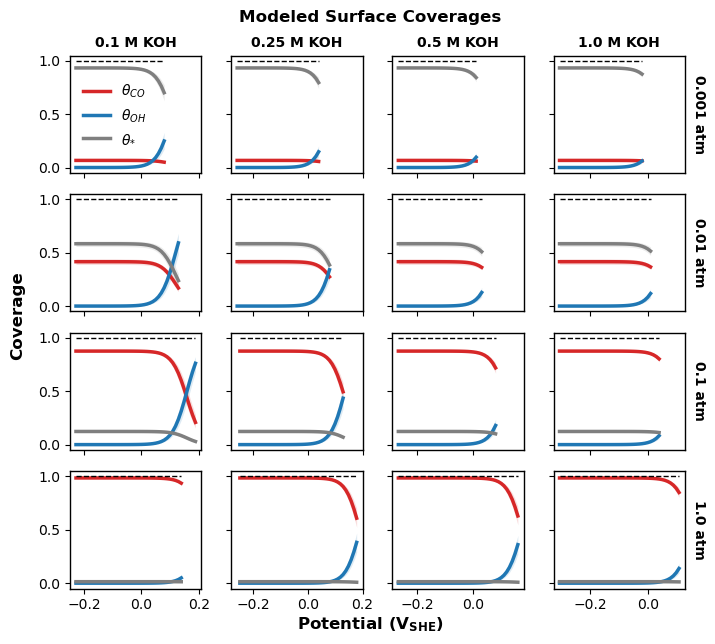

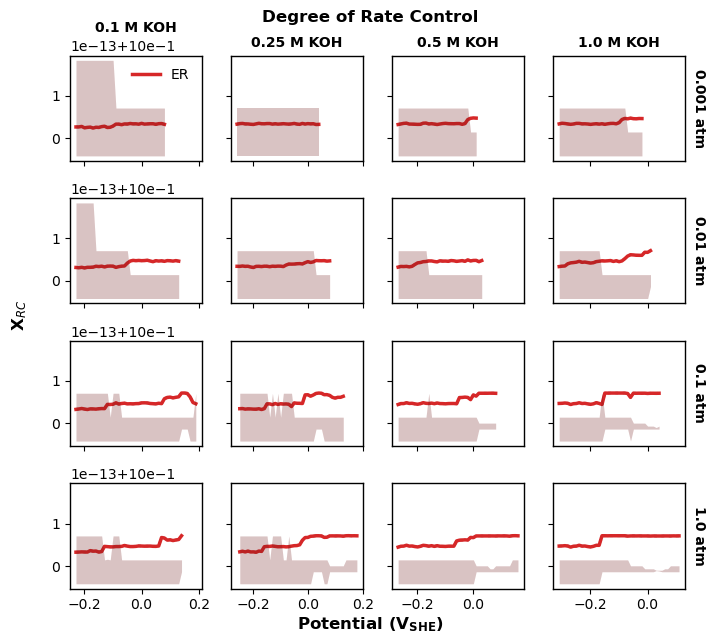

In [3]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2)
plot_model_fits(trace_ER_2, ppc_ER_2); plot_coverages(trace_ER_2)
plot_drc(ER_2, trace_ER_2, perturb_vars=['Gact2_0'], perturb_labels=['ER'])

# ER 1 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.42,7
,3000,0,0.50,7
,3000,0,0.46,7
,3000,0,0.41,3


Computed from 4000 posterior samples and 2324 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  5169.74    72.58
p_loo        8.29        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2324  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



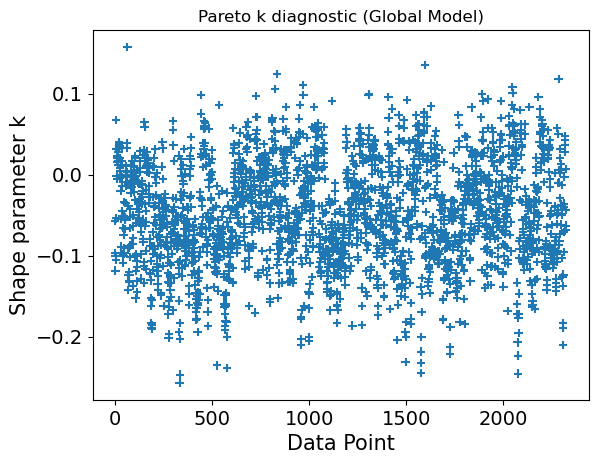

In [4]:
with pm.Model() as ER_1_2: 
    '''
    1. CO + * -> CO* (Fick) (Irr) (SSA)
    2. CO* + OH- -> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.75, sigma=0.1) # at 0V_SHE
    delta_BL = pm.TruncatedNormal('delta_BL', mu=10, sigma=5, lower=0) # in microns

    # Thermodynamics 
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1 = log_k1_fick - pt.log(delta_BL)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_k1 + np.log(P_CO_in) - (log_k2 + np.log(C_KOH_in))
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + np.log(C_KOH_in) + log_theta_CO 
    rate = observables(log_rate)

trace_ER_1_2, loo_ER_1_2 = fit_and_evaluate(ER_1_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0   0.089  0.003   0.085    0.094      0.000    0.000    3176.0    2747.0    1.0
Gact2_0     0.747  0.000   0.747    0.748      0.000    0.000    2399.0    2745.0    1.0
beta_2      0.277  0.003   0.271    0.282      0.000    0.000    2775.0    2820.0    1.0
delta_BL    9.458  0.223   9.041    9.873      0.004    0.004    3577.0    2814.0    1.0
sigma_rel   0.214  0.010   0.195    0.232      0.000    0.000    1397.0    1815.0    1.0
sigma_base  0.000  0.000   0.000    0.001      0.000    0.000    2297.0    1368.0    1.0
exponent    1.605  0.030   1.546    1.661      0.001    0.001    1402.0    1943.0    1.0


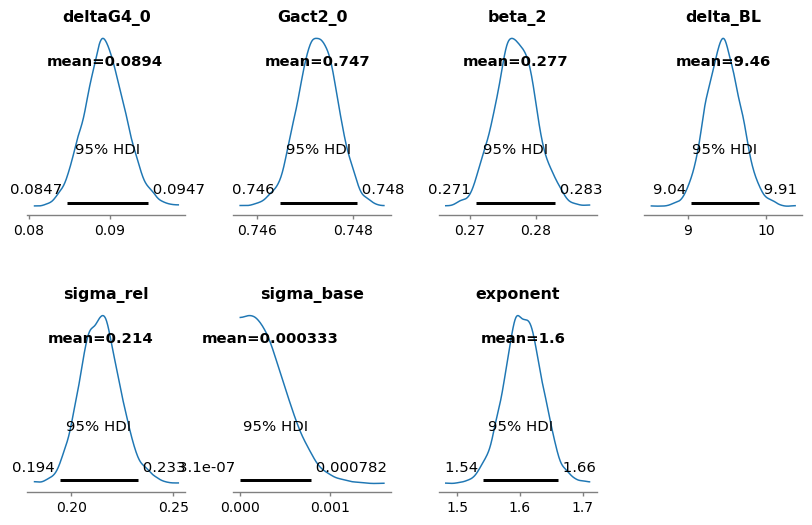

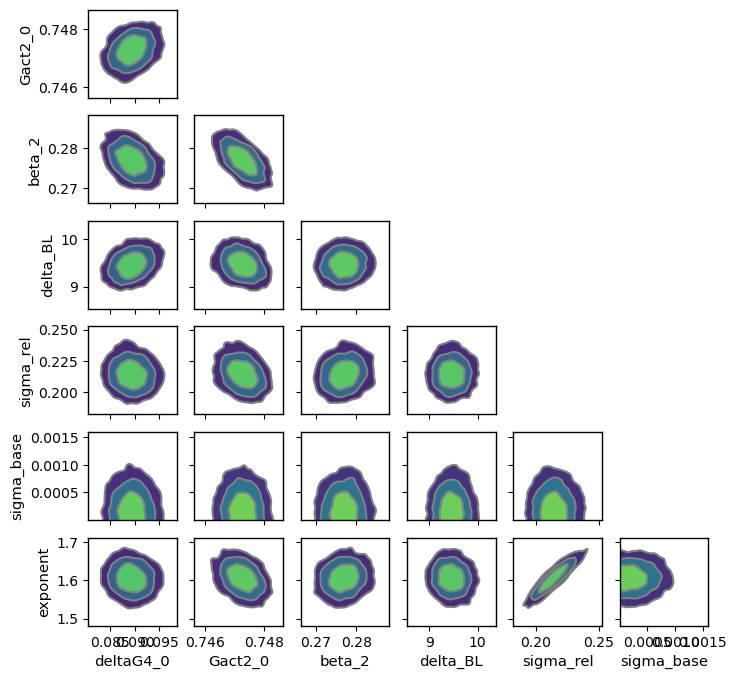

Sampling: [rate]


rate: 0.831


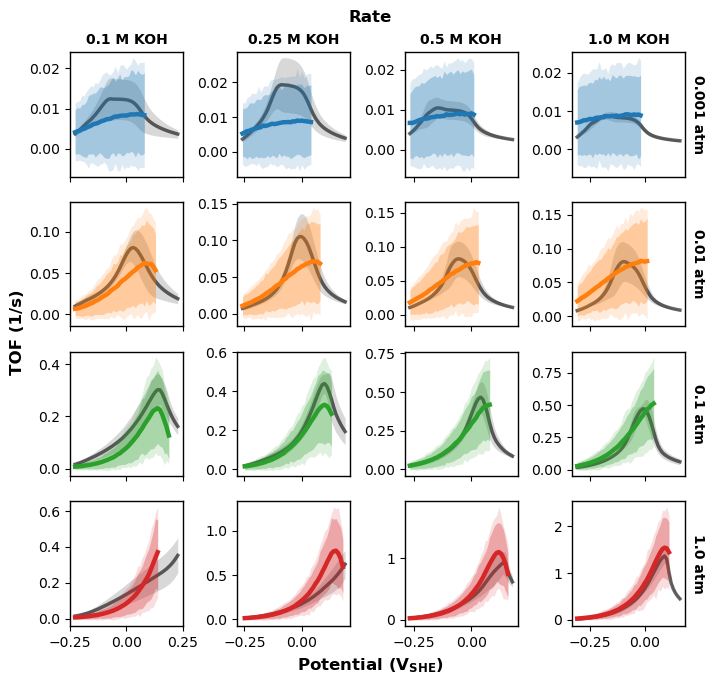

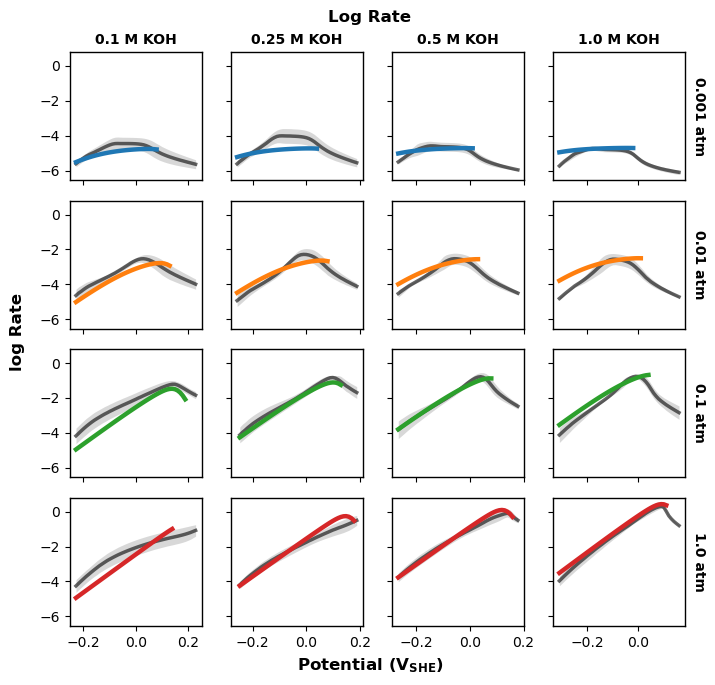

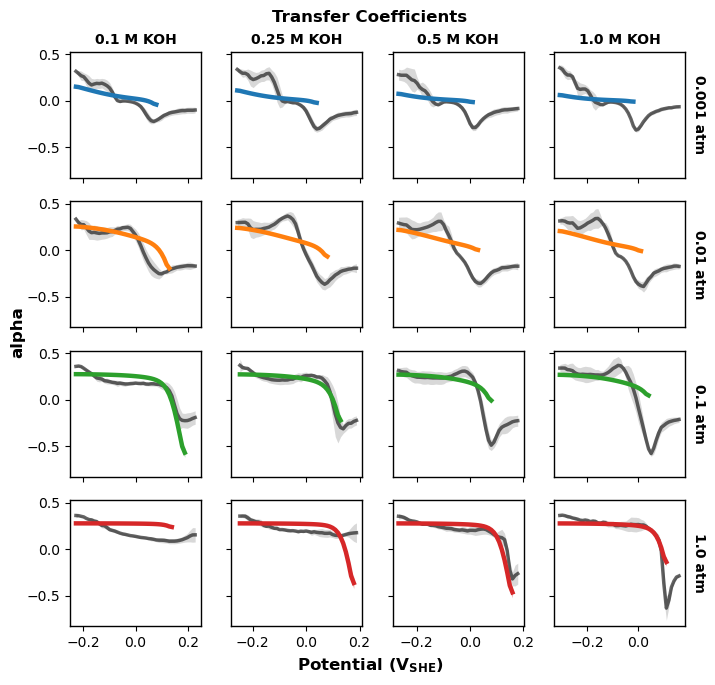

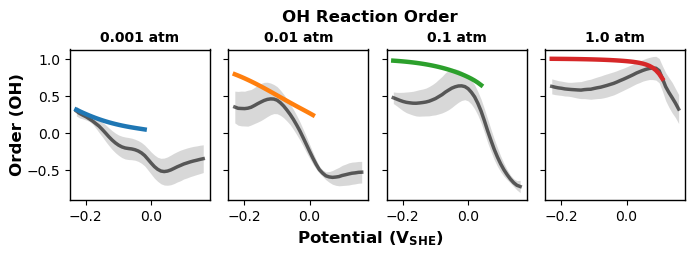

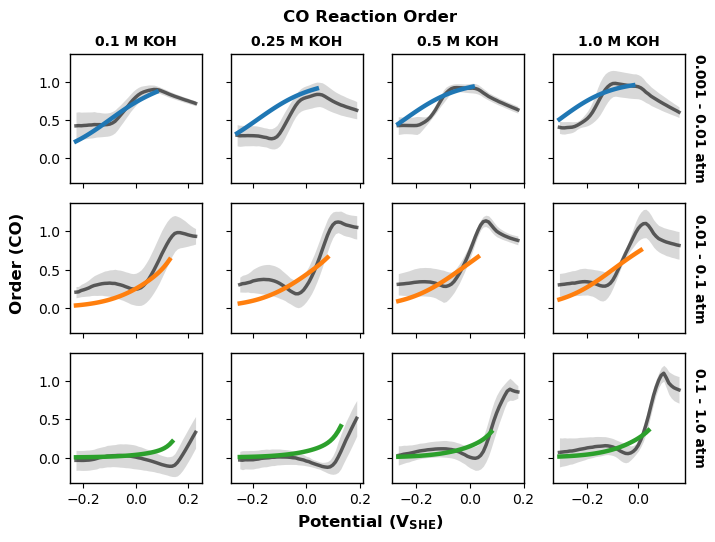

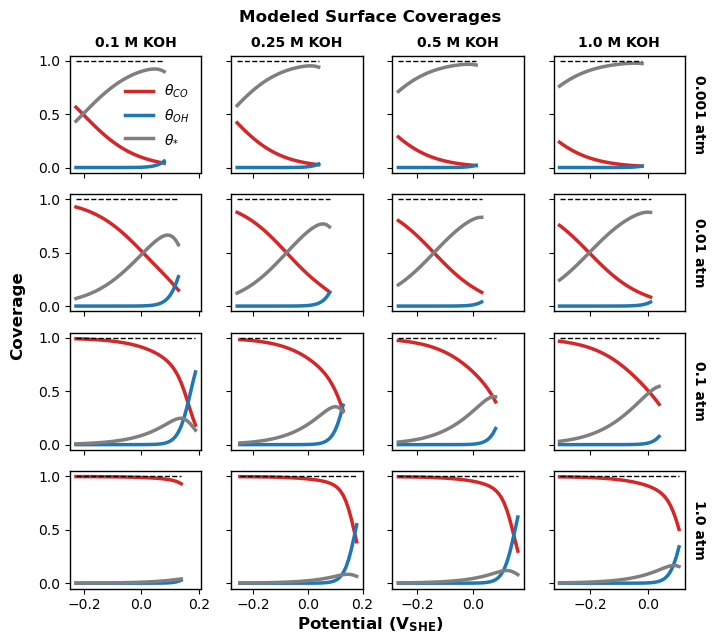

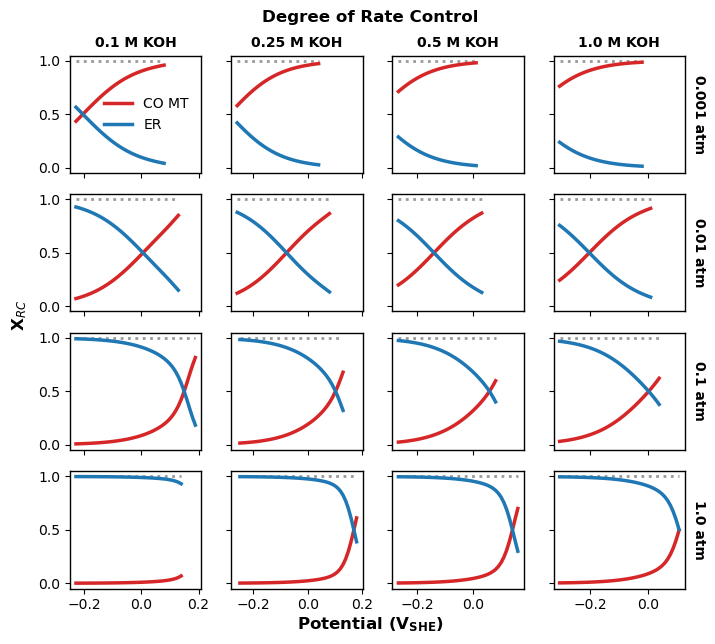

In [5]:
ppc_ER_1_2 = plot_posteriors(trace_ER_1_2, ER_1_2)
plot_model_fits(trace_ER_1_2, ppc_ER_1_2); plot_coverages(trace_ER_1_2)
plot_drc(ER_1_2, trace_ER_1_2, perturb_vars=['delta_BL', 'Gact2_0'], perturb_labels=['CO MT', 'ER'], 
         var_types={'delta_BL': 'resistance', 'Gact2_0': 'Gact'})

# ER 1 2 Kinetics

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.16,31
,3000,0,0.14,63
,3000,0,0.09,127
,3000,0,0.14,31


Computed from 4000 posterior samples and 2324 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  5119.89    70.16
p_loo        8.94        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2324  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



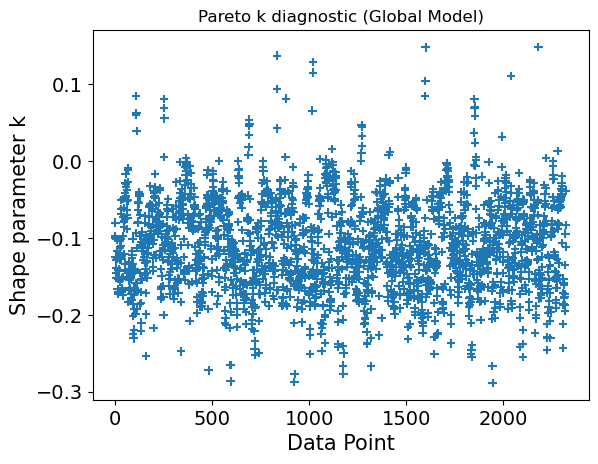

In [6]:
with pm.Model() as ER_1_2_kin: 
    '''
    1. CO + * <-> CO* (Fick) (SSA)
    2. CO* + OH- -> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.5, sigma=0.2)
    Gact1_0 = pm.TruncatedNormal('Gact1_0', mu=0.6, sigma=0.2, lower=0, upper=0.8) # Kinetic barrier for adsorption
    deltaG4_0 = pm.TruncatedNormal('deltaG4_0', mu=0.0, sigma=0.1, lower=-0.2, upper=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.75, sigma=0.1, lower=0.7, upper=0.8) # at 0V_SHE
    delta_BL = pm.TruncatedNormal('delta_BL', mu=9.46, sigma=0.221, lower=1) # in microns

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact1 = Gact1_0
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1_ads = np.log(kb_J*T/h) - Gact1/(kb_eV*T)
    log_k1_des = log_k1_ads - log_K1
    log_k1_MT = log_k1_fick - pt.log(delta_BL)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    K_OH = pt.exp(log_K4)
    k1_ads = pt.exp(log_k1_ads)
    k1_des = pt.exp(log_k1_des)
    k2 = pt.exp(log_k2)
    k1_MT = pt.exp(log_k1_MT)
    K_CO_kin = k1_ads /(k1_des + k2*C_KOH_in)
    term_OH = 1.0 + K_OH*C_KOH_in
    A = k1_MT*K_CO_kin
    B = k1_MT*term_OH + K_CO_kin*(k2*C_KOH_in - k1_MT*P_CO_in)
    C = -k1_MT*P_CO_in*term_OH
    P_int = (-B + pt.sqrt(B**2 - 4 * A * C)) / (2 * A)

    log_term_CO = pt.log(K_CO_kin) + pt.log(P_int)
    log_term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(log_term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, log_term_CO, log_term_OH]), axis=0)
    
    log_theta_CO = log_term_CO + log_theta
    log_theta_OH = log_term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate_model = log_k2 + np.log(C_KOH_in) + log_theta_CO 
    log_rate = observables(log_rate_model) 

trace_ER_1_2_kin, loo_ER_1_2_kin = fit_and_evaluate(ER_1_2_kin, target_accept=0.99)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.300  0.174  -0.673   -0.181      0.024    0.018      77.0     216.0   1.03
Gact1_0     0.657  0.003   0.653    0.662      0.000    0.000     180.0    1257.0   1.01
deltaG4_0   0.062  0.004   0.056    0.069      0.000    0.000     327.0    1591.0   1.01
beta_2      0.270  0.003   0.265    0.275      0.000    0.000    2986.0    2732.0   1.00
Gact2_0     0.750  0.000   0.749    0.751      0.000    0.000    2938.0    2792.0   1.00
delta_BL    8.927  0.214   8.534    9.331      0.004    0.003    3008.0    2804.0   1.00
sigma_rel   0.182  0.008   0.167    0.198      0.000    0.000    1836.0    2149.0   1.00
sigma_base  0.000  0.000   0.000    0.001      0.000    0.000    1599.0    1361.0   1.01
exponent    1.462  0.030   1.405    1.517      0.001    0.001    1709.0    2166.0   1.00


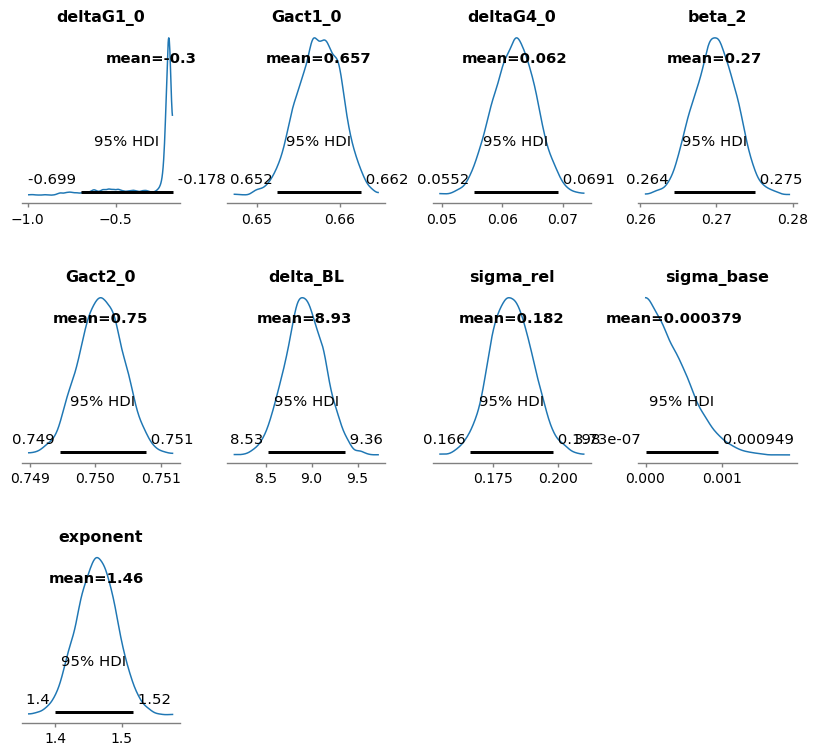

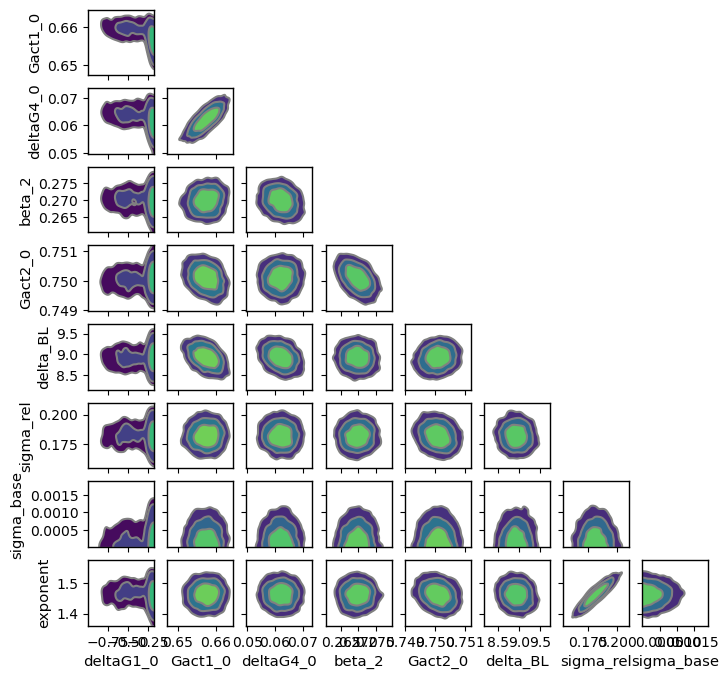

Sampling: [rate]


rate: 0.853


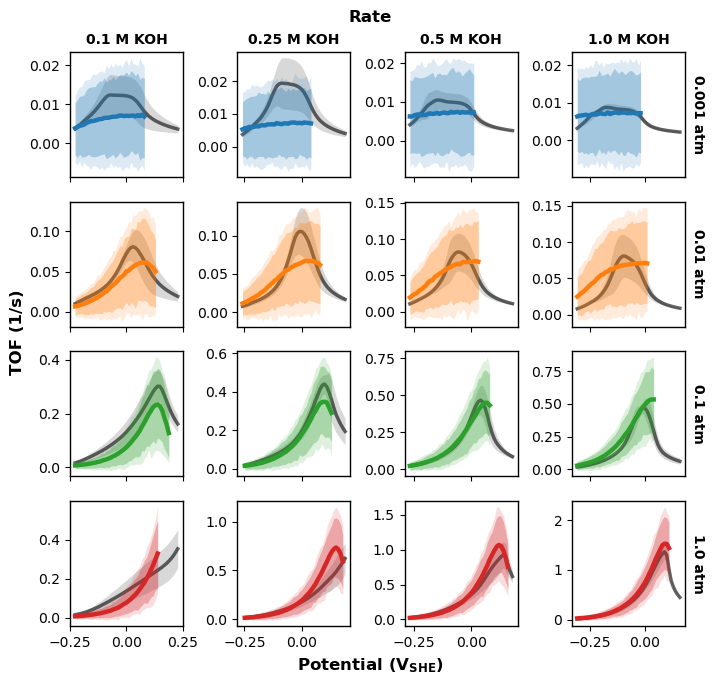

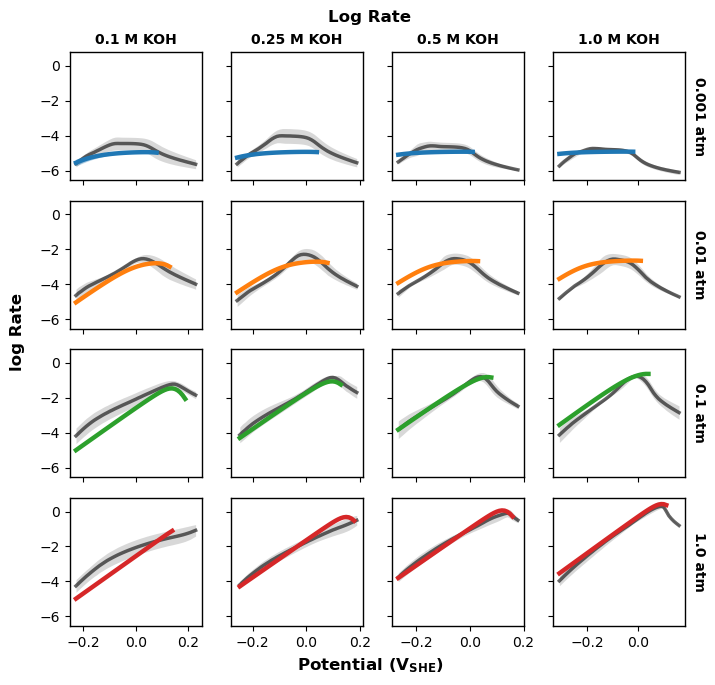

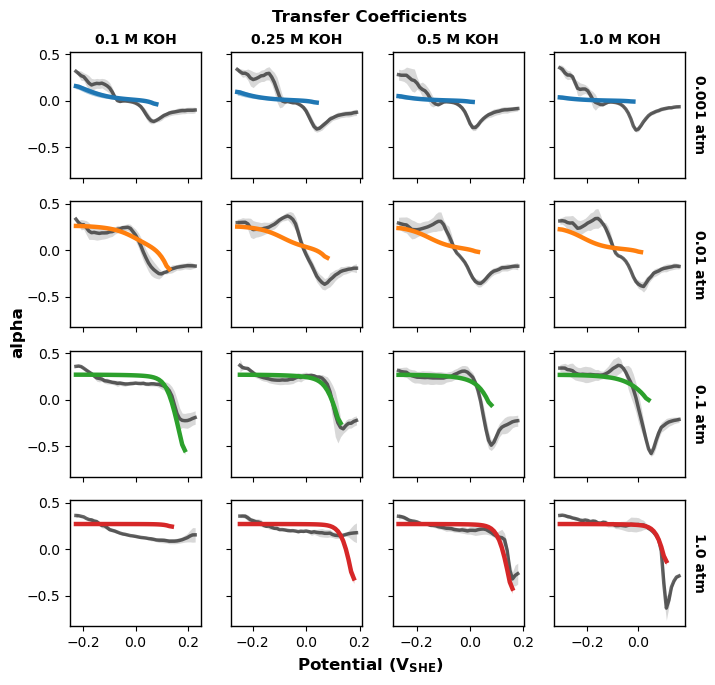

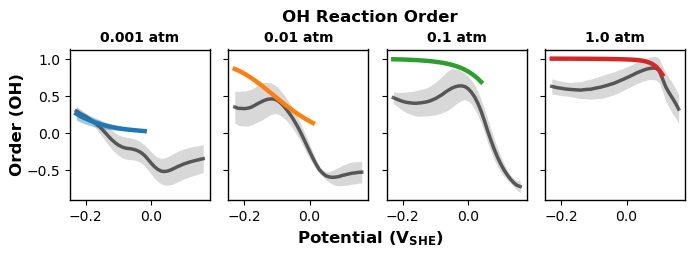

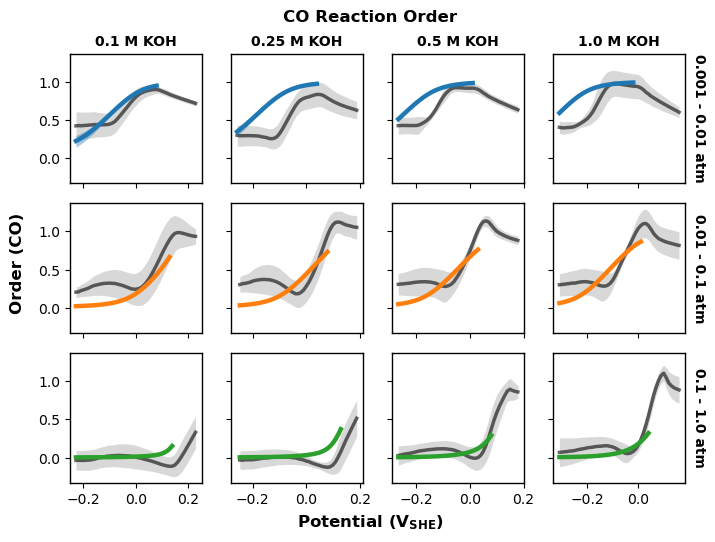

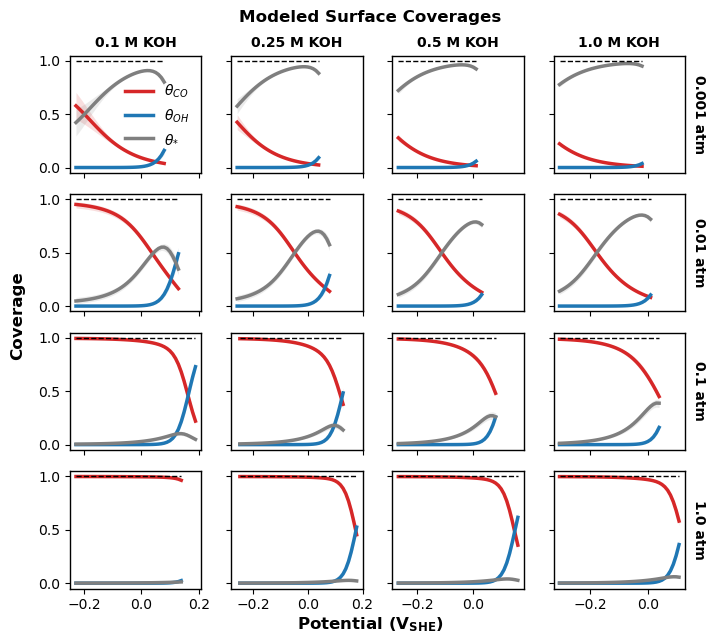

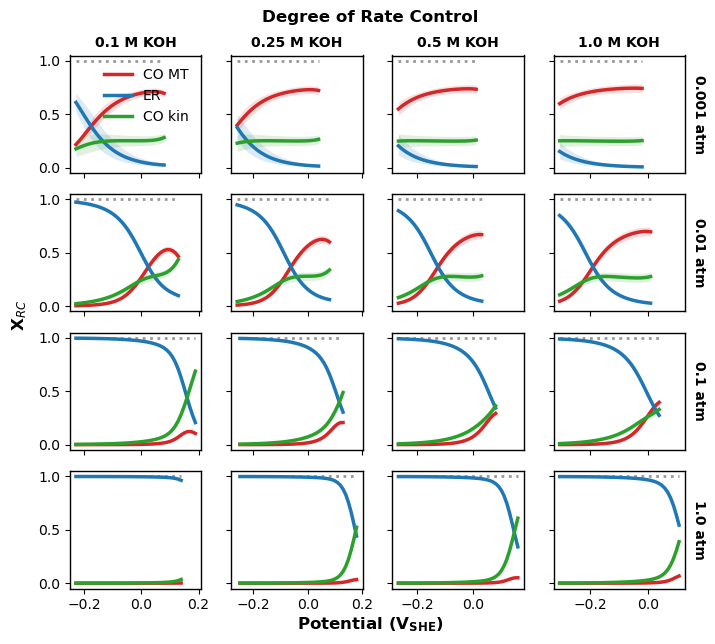

In [7]:
ppc_ER_1_2_kin = plot_posteriors(trace_ER_1_2_kin, ER_1_2_kin)
plot_model_fits(trace_ER_1_2_kin, ppc_ER_1_2_kin); plot_coverages(trace_ER_1_2_kin)
plot_drc(ER_1_2_kin, trace_ER_1_2_kin, perturb_vars=['delta_BL', 'Gact2_0','Gact1_0'], perturb_labels=['CO MT', 'ER', 'CO kin'], 
        var_types={'delta_BL': 'resistance', 'Gact1_0': 'Gact', 'Gact2_0': 'Gact'})

Output()

Interfacial Pressure Range: 0.00018 to 0.99939 atm


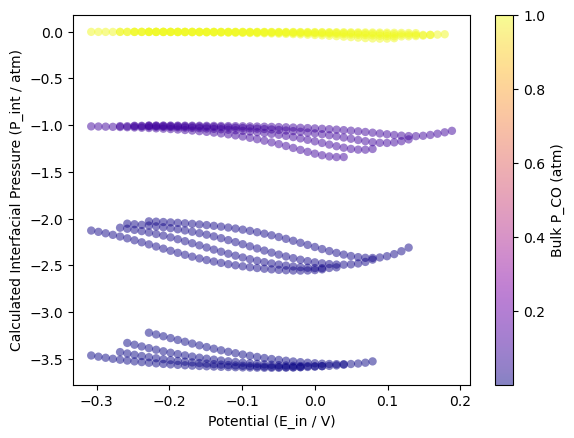

In [8]:
with ER_1_2_kin:
    pm.Deterministic('P_int_save', P_int)

# Pass the posterior group specifically to prevent PyMC's KeyError
trace_updated = pm.compute_deterministics(trace_ER_1_2_kin.posterior, model=ER_1_2_kin)

p_int_samples = trace_updated['P_int_save'].values
p_int_mean = p_int_samples.mean(axis=(0, 1))

print(f"Interfacial Pressure Range: {p_int_samples.min():.5f} to {p_int_samples.max():.5f} atm")

plt.scatter(E_in, np.log10(p_int_mean), c=P_CO_in, cmap='plasma', alpha=0.5, edgecolor='none')
plt.colorbar(label='Bulk P_CO (atm)')
plt.xlabel('Potential (E_in / V)')
plt.ylabel('Calculated Interfacial Pressure (P_int / atm)')
plt.show()

# ER LH 1 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.43,7
,3000,0,0.41,15
,3000,0,0.36,15
,3000,0,0.41,15


Computed from 4000 posterior samples and 2324 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  5173.65    72.38
p_loo        8.98        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2324  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



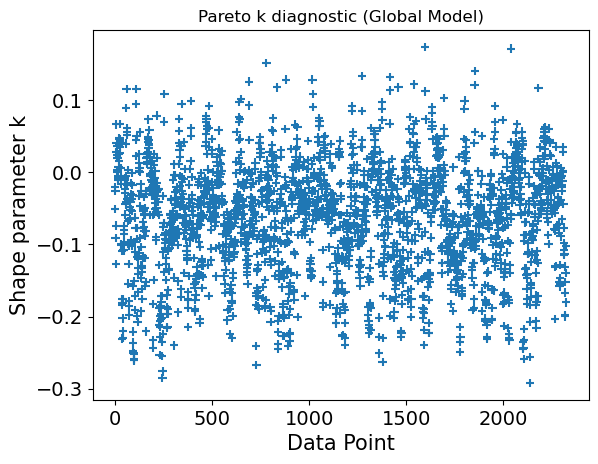

In [9]:
with pm.Model() as ER_LH_1_2:
    '''
    1. CO + * <-> CO* (Fick) (Irr) (SSA)
    2a. CO* + OH- -> COOH* + (e-) (SSA)
    2b. CO* + OH* -> COOH* + * (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.75, sigma=0.1) # at 0V_SHE
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.75, sigma=0.1)
    delta_BL = pm.TruncatedNormal('delta_BL', mu=10, sigma=5, lower=0) # in microns

    # Thermodynamics 
    deltaG4 = deltaG4_0 - E_in
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1 = log_k1_fick - pt.log(delta_BL)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_OH = log_K4 + np.log(C_KOH_in)
    gamma_OH_lin = pt.exp(term_OH)
    k1_fwd_lin = pt.exp(log_k1 + np.log(P_CO_in))
    k2_ER_lin = pt.exp(log_k2_ER + np.log(C_KOH_in))
    k2_LH_lin = pt.exp(log_k2_LH + term_OH)
    site_block = 1.0 + gamma_OH_lin
    a_term = k2_ER_lin
    b_term = k2_ER_lin * site_block + k2_LH_lin - k1_fwd_lin
    c_term = - k1_fwd_lin * site_block
    gamma_CO_lin = (-b_term + pt.sqrt(b_term**2 - 4 * a_term * c_term)) / (2 * a_term)
    term_CO = pt.log(gamma_CO_lin)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    
    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate_ER = log_k2_ER + np.log(C_KOH_in) + log_theta_CO
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH
    log_rate = pt.logaddexp(log_rate_ER, log_rate_LH)
    rate = observables(log_rate) 

trace_ER_LH_1_2, loo_ER_LH_1_2 = fit_and_evaluate(ER_LH_1_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0   0.086  0.003   0.081    0.091      0.000    0.000    2306.0    1529.0   1.01
Gact2_ER_0  0.748  0.000   0.747    0.748      0.000    0.000    2153.0    2422.0   1.00
Gact2_LH_0  0.763  0.023   0.740    0.789      0.002    0.006     813.0     357.0   1.01
beta_2      0.274  0.003   0.268    0.280      0.000    0.000    2970.0    2532.0   1.00
delta_BL    9.471  0.208   9.085    9.868      0.004    0.003    3257.0    2771.0   1.00
sigma_rel   0.211  0.010   0.192    0.228      0.000    0.000    1589.0    1989.0   1.00
sigma_base  0.000  0.000   0.000    0.001      0.000    0.000    2225.0    1394.0   1.00
exponent    1.595  0.030   1.535    1.647      0.001    0.001    1559.0    1866.0   1.00


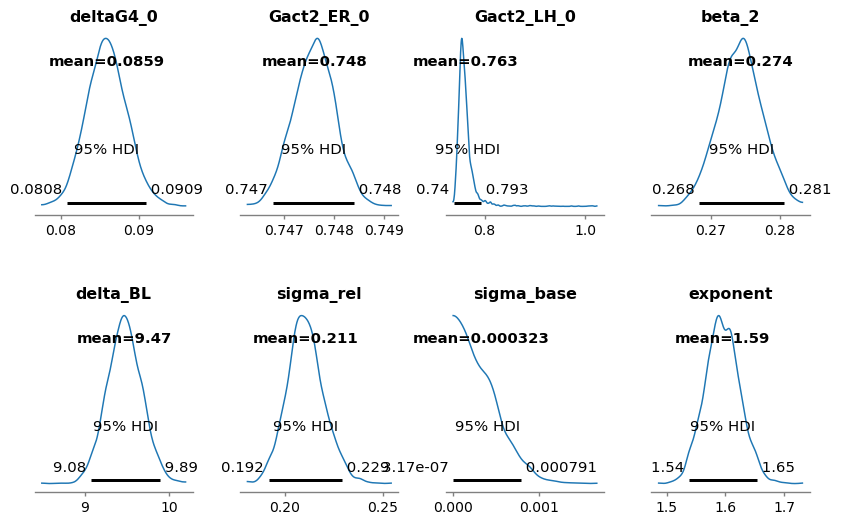

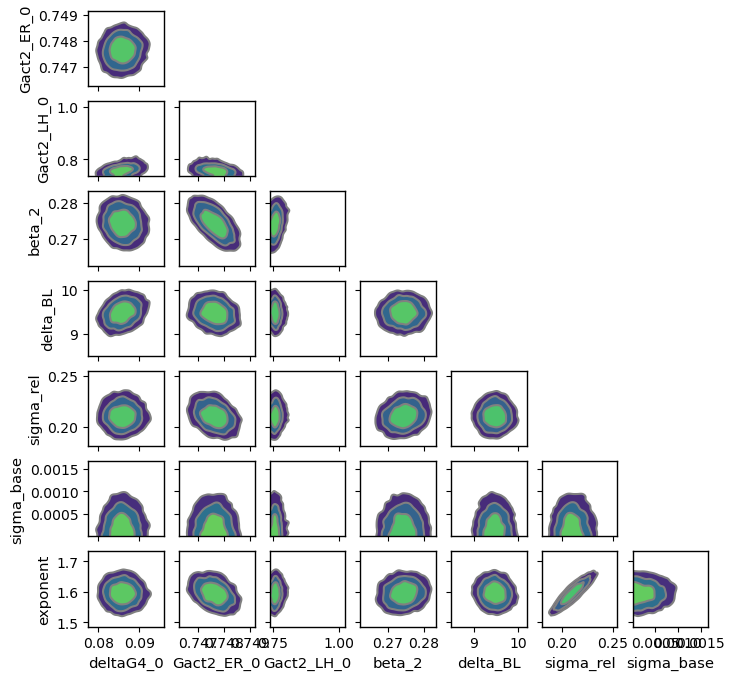

Sampling: [rate]


rate: 0.833


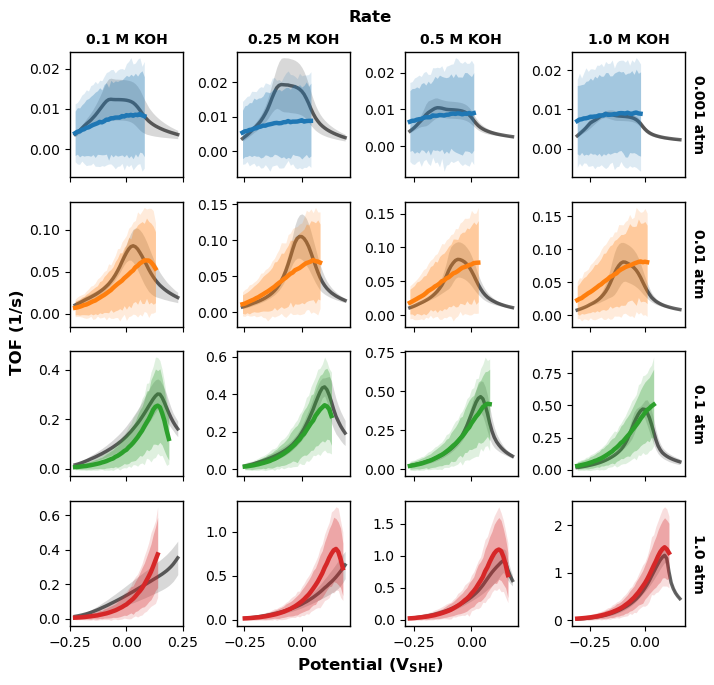

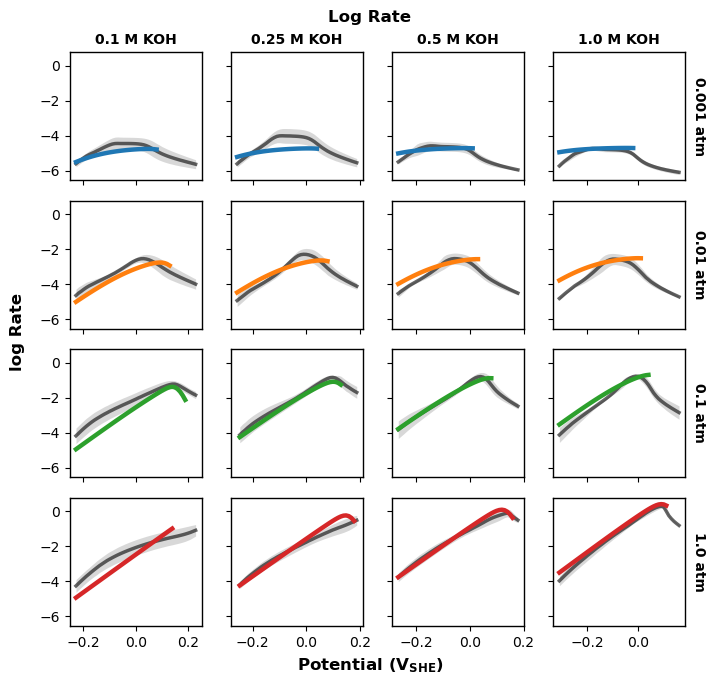

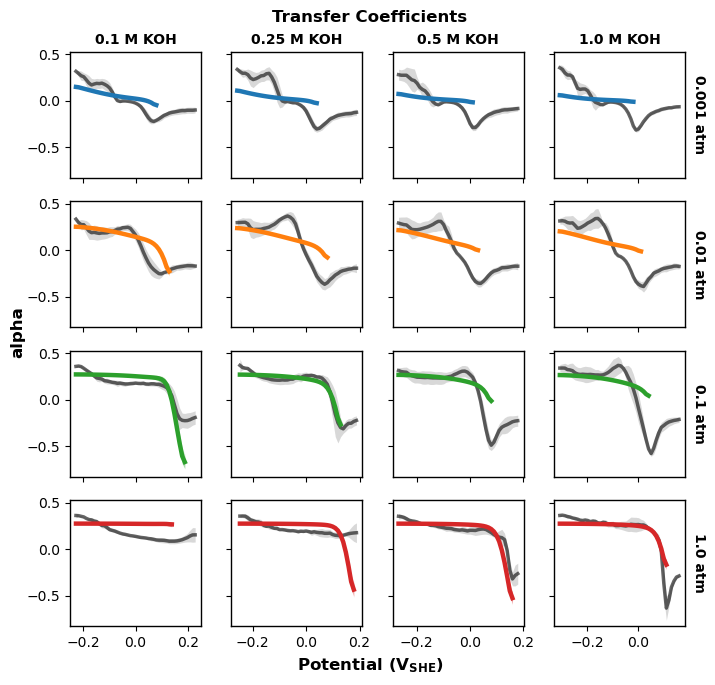

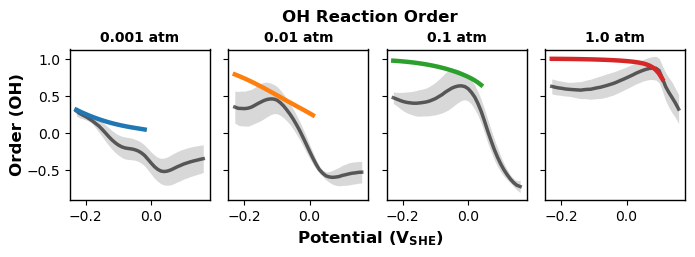

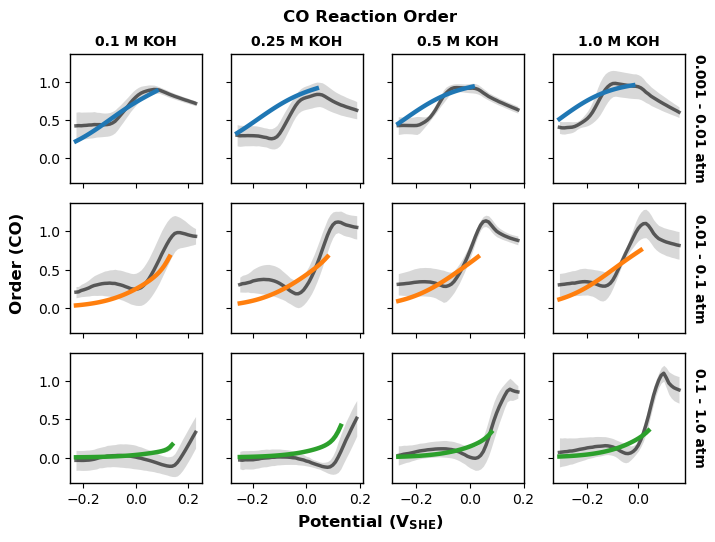

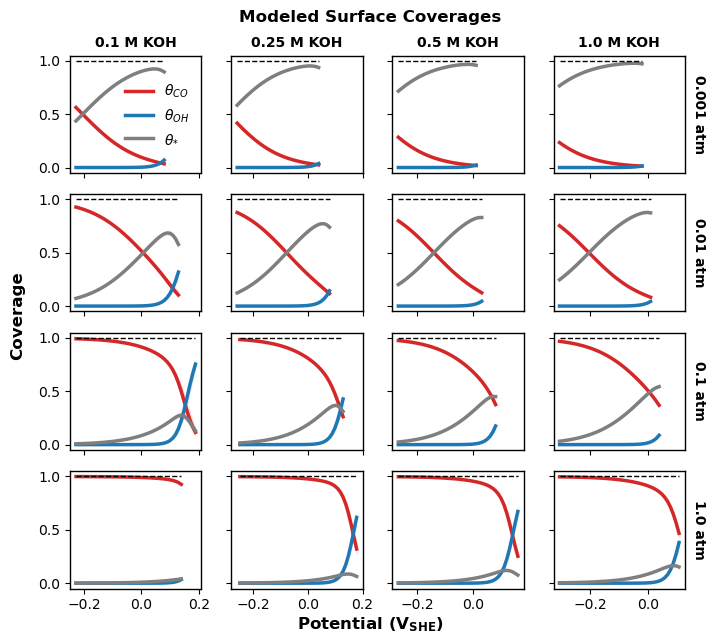

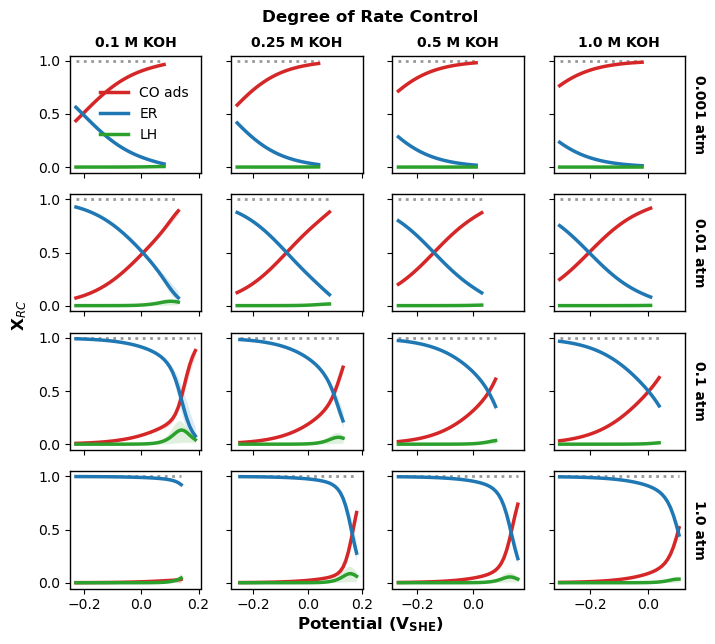

In [10]:
ppc_ER_LH_1_2 = plot_posteriors(trace_ER_LH_1_2, ER_LH_1_2)
plot_model_fits(trace_ER_LH_1_2, ppc_ER_LH_1_2); plot_coverages(trace_ER_LH_1_2)
plot_drc(ER_LH_1_2, trace_ER_LH_1_2, perturb_vars=['delta_BL', 'Gact2_ER_0', 'Gact2_LH_0'], perturb_labels=['CO ads', 'ER', 'LH'], 
         var_types={'delta_BL': 'resistance', 'Gact2_ER_0': 'Gact', 'Gact2_LH_0': 'Gact'})

# ER 1 2 Lateral - Model 1

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.26,31
,3000,0,0.27,39
,3000,0,0.25,31
,3000,0,0.28,7


Computed from 4000 posterior samples and 2324 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  5204.60    73.14
p_loo        9.73        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2324  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



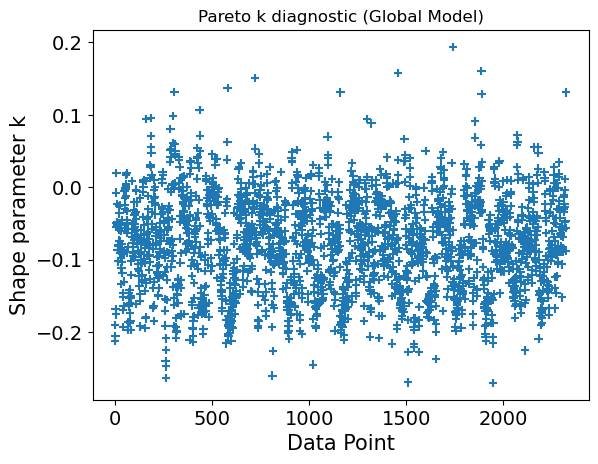

In [ ]:
with pm.Model() as ER_1_2_lateral:
    '''
    1. CO + * -> CO* (Fick) (Irr) (Unaffected by lateral interactions)
    2. CO* + OH- -> COOH* + (e-) (SSA with BEP - Lateral interactions speed this up)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA Frumkin)
    '''
    # Priors
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1)
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.75, sigma=0.1, lower=0.7)
    delta_BL = pm.TruncatedNormal('delta_BL', mu=9.46, sigma=0.221, lower=1) # in microns

    # z_CO = pt.as_tensor_variable(0.0) 
    # z_OH = pt.as_tensor_variable(0.0)
    z_CO = pm.TruncatedNormal('z_CO', lower=0, mu=0.2, sigma=0.2)
    z_OH = pm.TruncatedNormal('z_OH', lower=0, mu=0.2, sigma=0.2)

    bep_alpha = 0.65 # BEP transfer coefficient (how much repulsion lowers Gact2)

    # Thermodynamics
    deltaG4_base = deltaG4_0 - E_in
    Gact2_base = Gact2_0 - beta_2 * E_in
    log_K4_base = -deltaG4_base / (kb_eV * T)
    log_k1_base = log_k1_fick - pt.log(delta_BL) # Pure Fickian diffusion
    log_k2_base = np.log(kb_J * T / h) - Gact2_base / (kb_eV * T)

    # Initial guess: Langmuir (No interactions)
    term_CO_base = log_k1_base + np.log(P_CO_in) - (log_k2_base + np.log(C_KOH_in))
    term_OH_base = log_K4_base + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO_base)   
    log_theta_init = -pt.logsumexp(pt.stack([zeros, term_CO_base, term_OH_base]), axis=0)
    theta_CO_guess = pt.exp(term_CO_base + log_theta_init)
    theta_OH_guess = pt.exp(term_OH_base + log_theta_init)

    # Iterative solver setup 
    n_iter_steps = 30
    damp_array = pt.as_tensor_variable(np.maximum(0.6 * (0.80 ** np.arange(n_iter_steps)), 0.1))
    
    def frumkin_step(damp, theta_CO_prev, theta_OH_prev, log_k1_base, log_k2_base, log_K4_base, z_CO, z_OH, kb_T, zeros, P_CO_in, C_KOH_in):

        penalty_CO = (z_CO * theta_CO_prev) / kb_T
        penalty_OH = (z_OH * theta_OH_prev) / kb_T 
        log_K4_iter = log_K4_base - penalty_OH
        log_k2_iter = log_k2_base + bep_alpha * penalty_CO 
        log_k1_iter = log_k1_base 
        
        term_CO_iter = log_k1_iter + np.log(P_CO_in) - (log_k2_iter + np.log(C_KOH_in)) 
        term_OH_iter = log_K4_iter + np.log(C_KOH_in)
        log_theta_iter = -pt.logsumexp(pt.stack([zeros, term_CO_iter, term_OH_iter]), axis=0)
        theta_CO_calc = pt.exp(term_CO_iter + log_theta_iter)
        theta_OH_calc = pt.exp(term_OH_iter + log_theta_iter)
        
        theta_CO_new = damp * theta_CO_calc + (1.0 - damp) * theta_CO_prev
        theta_OH_new = damp * theta_OH_calc + (1.0 - damp) * theta_OH_prev
        return theta_CO_new, theta_OH_new

    # Run the iterative solver
    theta_CO_seq, theta_OH_seq = pytensor.scan(
        fn=frumkin_step, sequences=[damp_array], 
        outputs_info=[theta_CO_guess, theta_OH_guess],
        non_sequences=[log_k1_base, log_k2_base, log_K4_base, z_CO, z_OH, kb_eV * T, zeros, P_CO_in, C_KOH_in], 
        n_steps=n_iter_steps, return_updates=False
    )
    theta_CO_final = theta_CO_seq[-1]
    theta_OH_final = theta_OH_seq[-1]

    CO_error = pt.max(pt.abs(theta_CO_seq[-1] - theta_CO_seq[-2])); pm.Deterministic('CO_converge_error', CO_error)
    OH_error = pt.max(pt.abs(theta_OH_seq[-1] - theta_OH_seq[-2])); pm.Deterministic('OH_converge_error', OH_error)
    theta_CO = pm.Deterministic('theta_CO', theta_CO_final)
    theta_OH = pm.Deterministic('theta_OH', theta_OH_final)
    theta_empty = pm.Deterministic('theta_empty', 1.0 - theta_CO_final - theta_OH_final)

    # Final Evaluation of kinetics with converged coverages
    penalty_CO_final = (z_CO * theta_CO_final) / (kb_eV * T) 
    log_k2_final = log_k2_base + bep_alpha * penalty_CO_final 

    # Rate expression uses the dynamically updated k2
    log_rate = log_k2_final + np.log(C_KOH_in) + pt.log(theta_CO_final)
    rate = observables(log_rate)

trace_ER_1_2_lateral, loo_ER_1_2_lateral = fit_and_evaluate(ER_1_2_lateral, target_accept=0.9)

                    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0          0.021  0.010   0.002    0.040      0.000    0.000    2066.0    1892.0   1.00
beta_2             0.294  0.004   0.286    0.302      0.000    0.000    2258.0    2110.0   1.00
Gact2_0            0.752  0.002   0.748    0.756      0.000    0.000     700.0     827.0   1.01
delta_BL           8.888  0.187   8.545    9.242      0.005    0.003    1512.0    2279.0   1.01
z_CO               0.012  0.004   0.004    0.019      0.000    0.000     641.0     870.0   1.01
z_OH               0.144  0.023   0.102    0.187      0.001    0.000    1820.0    2283.0   1.00
sigma_rel          0.223  0.011   0.203    0.244      0.000    0.000    1910.0    2285.0   1.00
sigma_base         0.000  0.000   0.000    0.001      0.000    0.000    2477.0    1186.0   1.00
exponent           1.638  0.033   1.573    1.695      0.001    0.001    1990.0    2457.0   1.00
CO_converge_error  0.000  0.000   0.000 

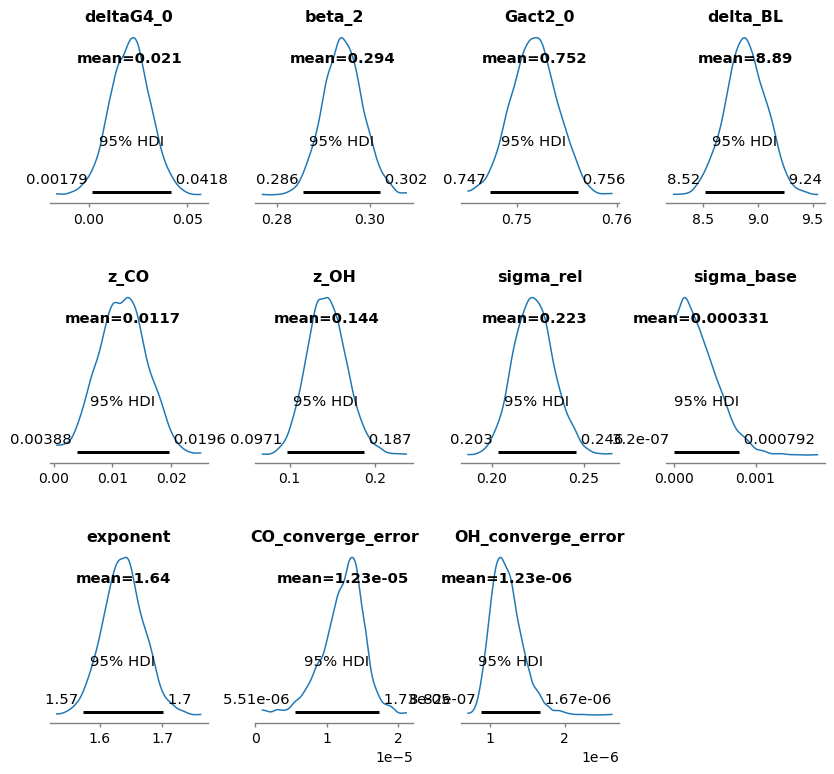

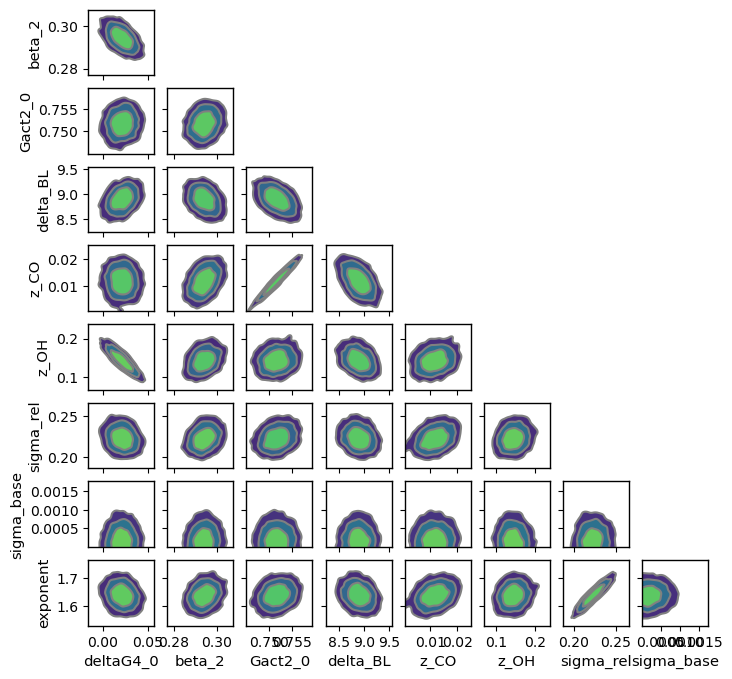

Sampling: [rate]


rate: 0.823


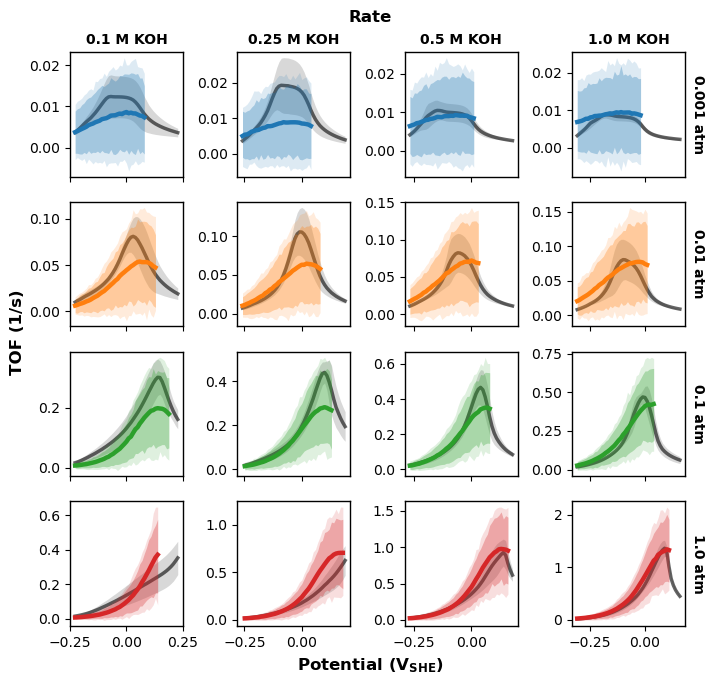

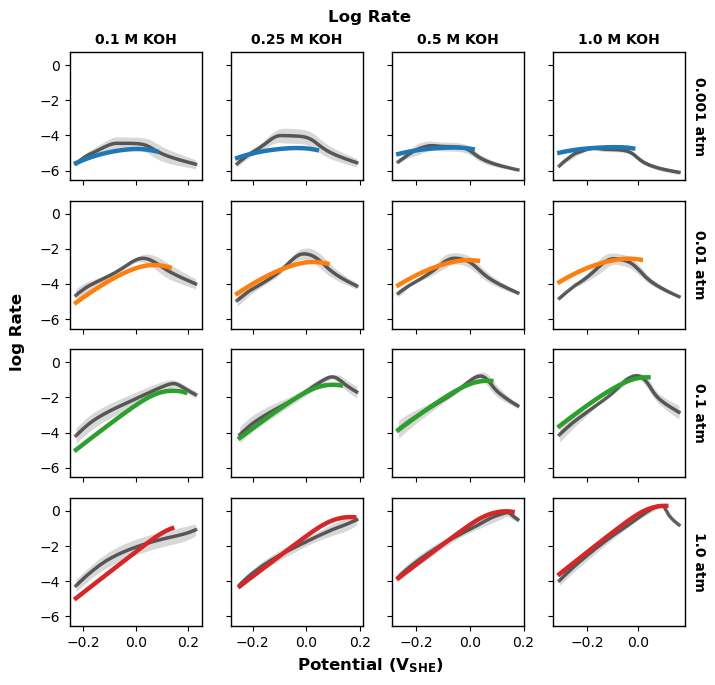

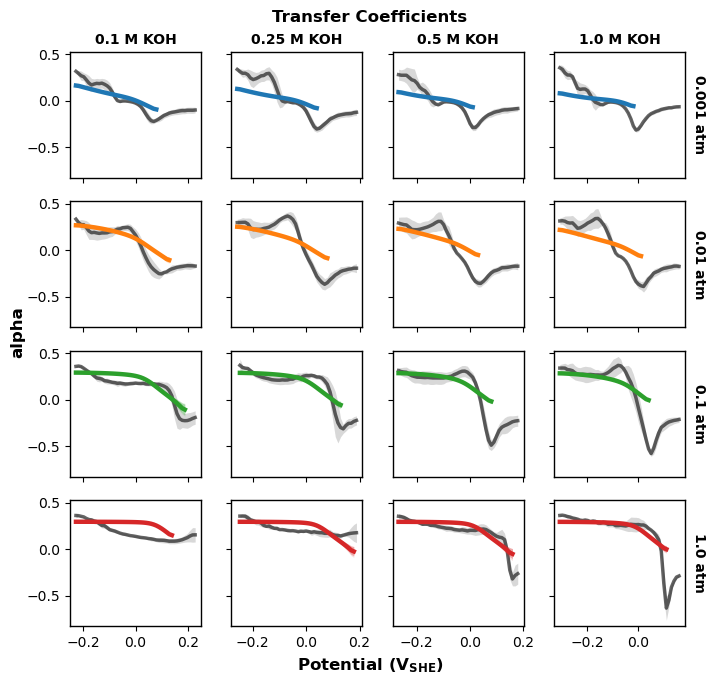

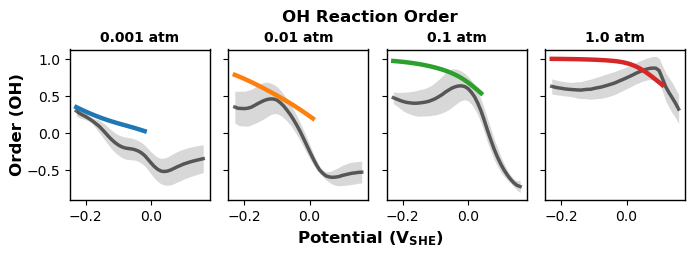

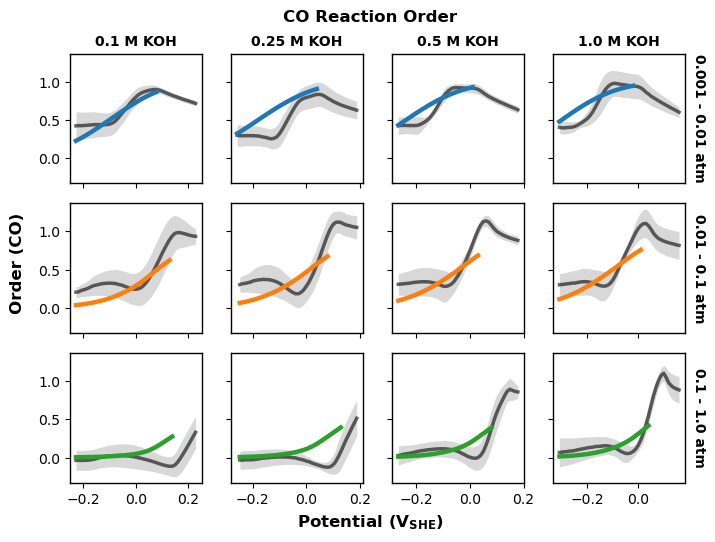

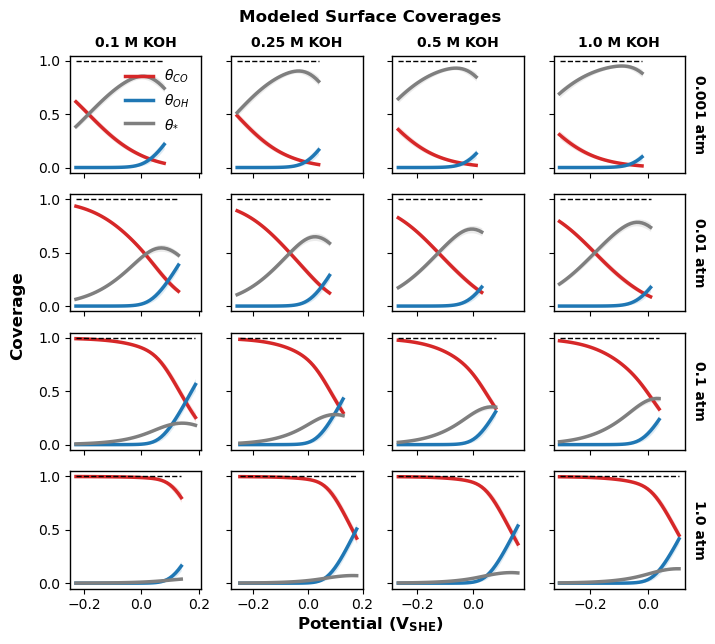

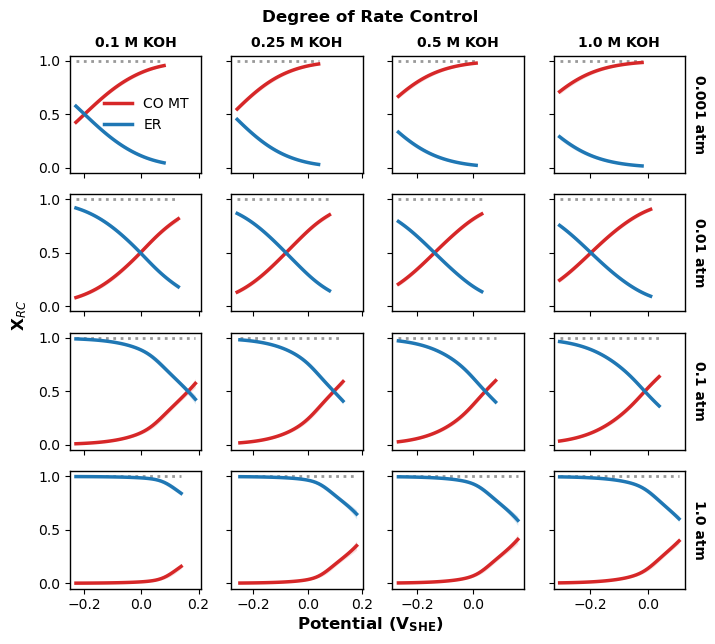

In [23]:
ppc_ER_1_2_lateral = plot_posteriors(trace_ER_1_2_lateral, ER_1_2_lateral)
plot_model_fits(trace_ER_1_2_lateral, ppc_ER_1_2_lateral); plot_coverages(trace_ER_1_2_lateral)
plot_drc(ER_1_2_lateral, trace_ER_1_2_lateral, perturb_vars=['delta_BL', 'Gact2_0'], perturb_labels=['CO MT', 'ER'], 
         var_types={'delta_BL': 'resistance', 'Gact2_0': 'Gact'})

# ER 1 2 Lateral - Model 2 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.15,31
,3000,0,0.16,31
,3000,0,0.17,23
,3000,0,0.17,111


Computed from 4000 posterior samples and 2324 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  5457.39    76.98
p_loo       10.30        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2324  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



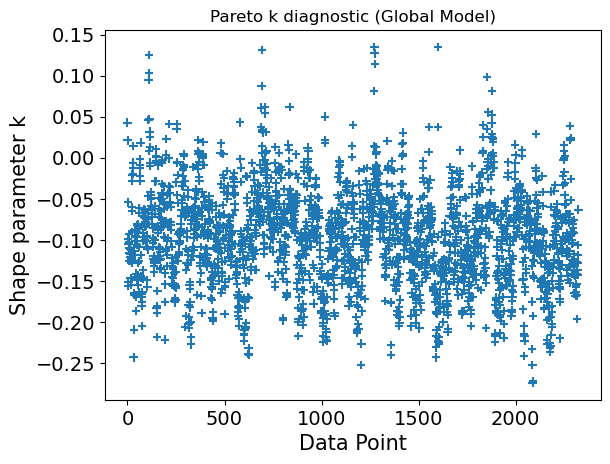

In [25]:
with pm.Model() as ER_1_2_lateral_2:
    '''
    1. CO + * -> CO* (Fick) (Irr) (Unaffected by lateral interactions)
    2. CO* + OH- -> COOH* + (e-) (SSA with BEP - Lateral interactions speed this up)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA Frumkin)
    '''
    # Priors
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1)
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.75, sigma=0.1, lower=0.7)
    delta_BL = pm.TruncatedNormal('delta_BL', mu=10, sigma=5, lower=0) # in microns

    # z_CO = pt.as_tensor_variable(0.0) 
    # z_OH = pt.as_tensor_variable(0.0)
    z_CO = pm.TruncatedNormal('z_CO', lower=0, mu=0.2, sigma=0.2)
    z_OH = pm.TruncatedNormal('z_OH', lower=0, mu=0.2, sigma=0.2)

    bep_alpha = 0.65 # BEP transfer coefficient (how much repulsion lowers Gact2)

    # Thermodynamics
    deltaG4_base = deltaG4_0 - E_in
    Gact2_base = Gact2_0 - beta_2 * E_in
    log_K4_base = -deltaG4_base / (kb_eV * T)
    log_k1_base = log_k1_fick - pt.log(delta_BL) # Pure Fickian diffusion
    log_k2_base = np.log(kb_J * T / h) - Gact2_base / (kb_eV * T)

    # Initial guess: Langmuir (No interactions)
    term_CO_base = log_k1_base + np.log(P_CO_in) - (log_k2_base + np.log(C_KOH_in))
    term_OH_base = log_K4_base + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO_base)   
    log_theta_init = -pt.logsumexp(pt.stack([zeros, term_CO_base, term_OH_base]), axis=0)
    theta_CO_guess = pt.exp(term_CO_base + log_theta_init)
    theta_OH_guess = pt.exp(term_OH_base + log_theta_init)

    # Iterative solver setup 
    n_iter_steps = 30
    damp_array = pt.as_tensor_variable(np.maximum(0.6 * (0.80 ** np.arange(n_iter_steps)), 0.1))
    
    def frumkin_step(damp, theta_CO_prev, theta_OH_prev, log_k1_base, log_k2_base, log_K4_base, z_CO, z_OH, kb_T, zeros, P_CO_in, C_KOH_in):

        penalty_CO = (z_CO * theta_CO_prev) / kb_T
        penalty_OH = (z_OH * theta_OH_prev) / kb_T 
        log_K4_iter = log_K4_base - penalty_OH
        log_k2_iter = log_k2_base + bep_alpha * penalty_CO 
        log_k1_iter = log_k1_base 
        
        term_CO_iter = log_k1_iter + np.log(P_CO_in) - (log_k2_iter + np.log(C_KOH_in)) 
        term_OH_iter = log_K4_iter + np.log(C_KOH_in)
        log_theta_iter = -pt.logsumexp(pt.stack([zeros, term_CO_iter, term_OH_iter]), axis=0)
        theta_CO_calc = pt.exp(term_CO_iter + log_theta_iter)
        theta_OH_calc = pt.exp(term_OH_iter + log_theta_iter)
        
        theta_CO_new = damp * theta_CO_calc + (1.0 - damp) * theta_CO_prev
        theta_OH_new = damp * theta_OH_calc + (1.0 - damp) * theta_OH_prev
        return theta_CO_new, theta_OH_new

    # Run the iterative solver
    theta_CO_seq, theta_OH_seq = pytensor.scan(
        fn=frumkin_step, sequences=[damp_array], 
        outputs_info=[theta_CO_guess, theta_OH_guess],
        non_sequences=[log_k1_base, log_k2_base, log_K4_base, z_CO, z_OH, kb_eV * T, zeros, P_CO_in, C_KOH_in], 
        n_steps=n_iter_steps, return_updates=False
    )
    theta_CO_final = theta_CO_seq[-1]
    theta_OH_final = theta_OH_seq[-1]

    CO_error = pt.max(pt.abs(theta_CO_seq[-1] - theta_CO_seq[-2])); pm.Deterministic('CO_converge_error', CO_error)
    OH_error = pt.max(pt.abs(theta_OH_seq[-1] - theta_OH_seq[-2])); pm.Deterministic('OH_converge_error', OH_error)
    theta_CO = pm.Deterministic('theta_CO', theta_CO_final)
    theta_OH = pm.Deterministic('theta_OH', theta_OH_final)
    theta_empty = pm.Deterministic('theta_empty', 1.0 - theta_CO_final - theta_OH_final)

    # Final Evaluation of kinetics with converged coverages
    penalty_CO_final = (z_CO * theta_CO_final) / (kb_eV * T) 
    log_k2_final = log_k2_base + bep_alpha * penalty_CO_final 

    # Rate expression uses the dynamically updated k2
    log_rate = log_k2_final + np.log(C_KOH_in) + pt.log(theta_CO_final)
    rate = observables(log_rate)

trace_ER_1_2_lateral_2, loo_ER_1_2_lateral_2 = fit_and_evaluate(ER_1_2_lateral_2, target_accept=0.9)

                    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0         -0.466  0.030  -0.520   -0.412      0.001    0.001     639.0     770.0   1.01
beta_2             0.555  0.011   0.535    0.576      0.000    0.000    1845.0    2016.0   1.00
Gact2_0            0.752  0.003   0.747    0.758      0.000    0.000    1048.0    1369.0   1.00
delta_BL           1.623  0.115   1.412    1.839      0.003    0.002    1089.0    1081.0   1.00
z_CO               0.136  0.008   0.120    0.151      0.000    0.000    1160.0    1051.0   1.00
z_OH               0.550  0.028   0.499    0.601      0.001    0.001     692.0     741.0   1.01
sigma_rel          0.314  0.014   0.287    0.341      0.000    0.000    2902.0    2687.0   1.00
sigma_base         0.000  0.000   0.000    0.001      0.000    0.000    2733.0    1827.0   1.00
exponent           1.960  0.030   1.905    2.015      0.001    0.000    2798.0    2556.0   1.00
CO_converge_error  0.000  0.000   0.000 

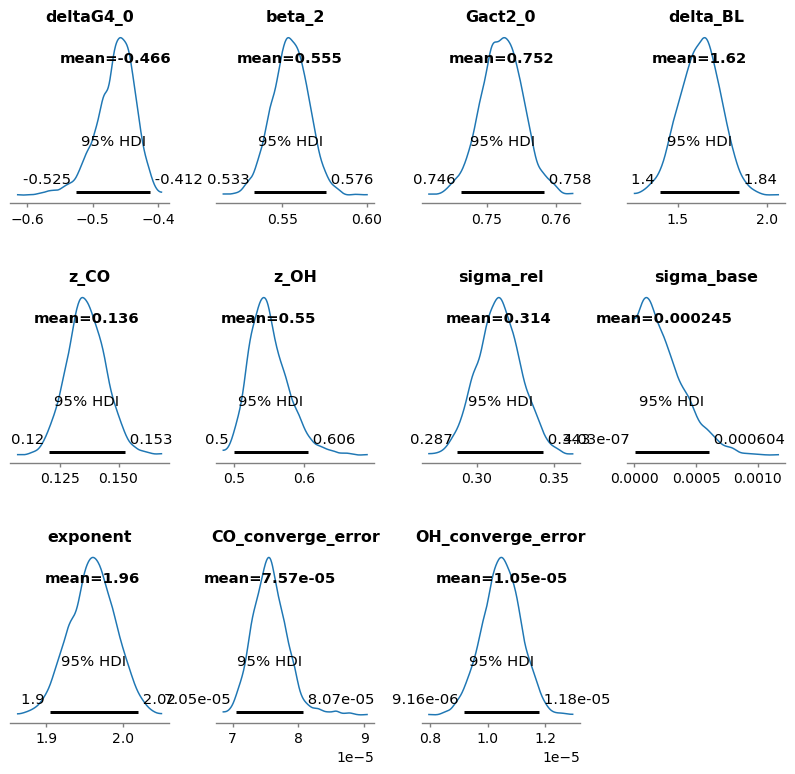

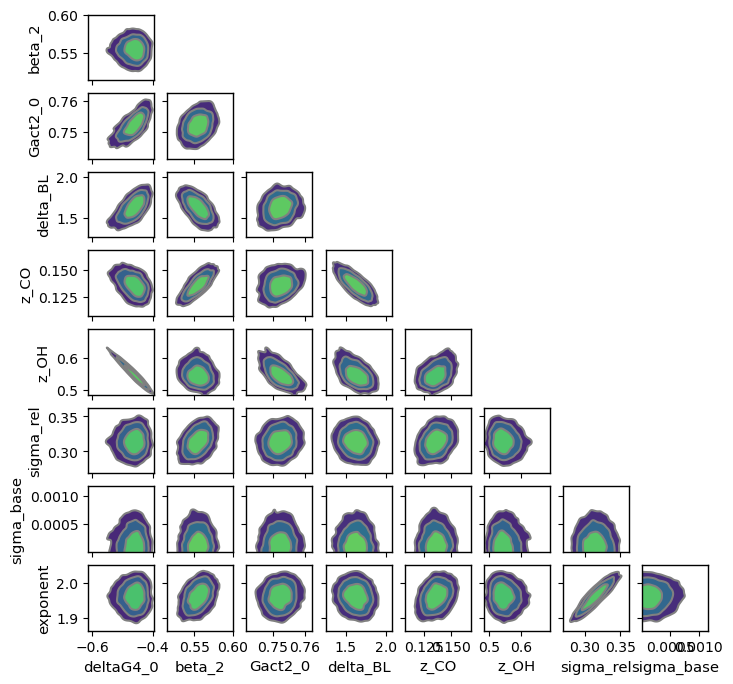

Sampling: [rate]


rate: 0.747


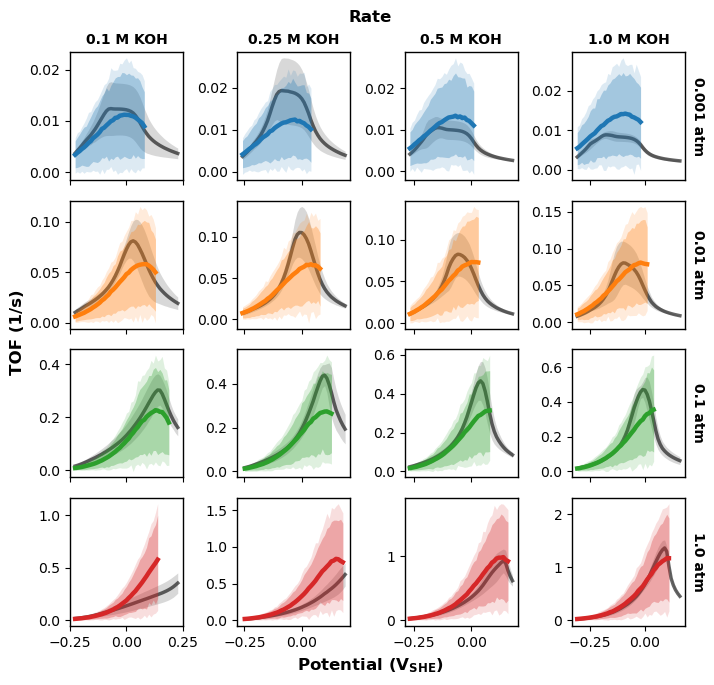

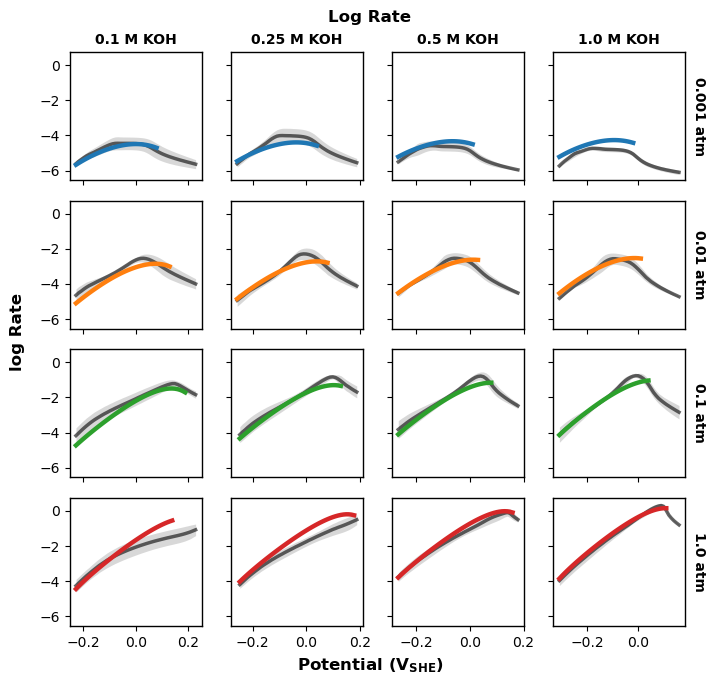

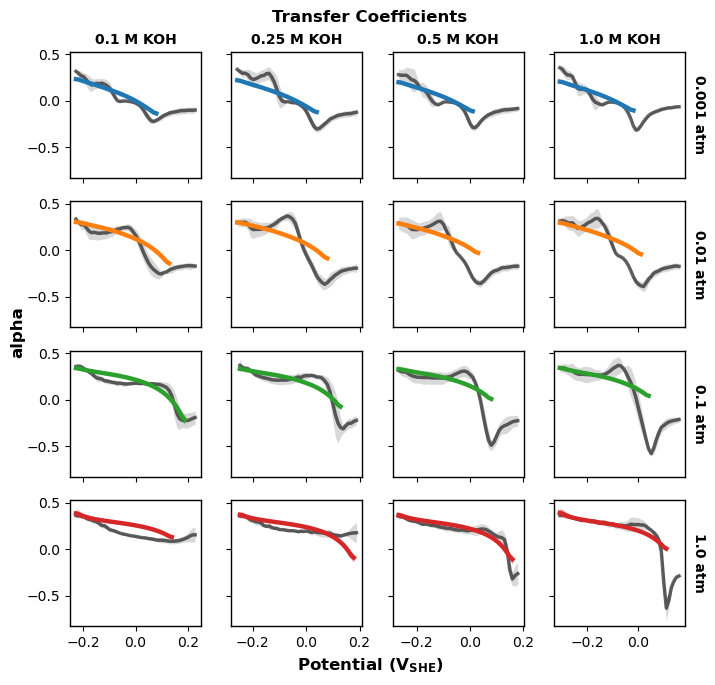

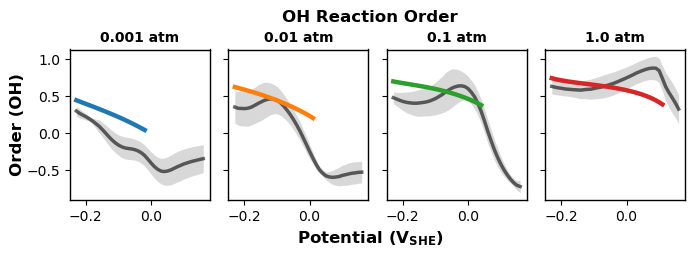

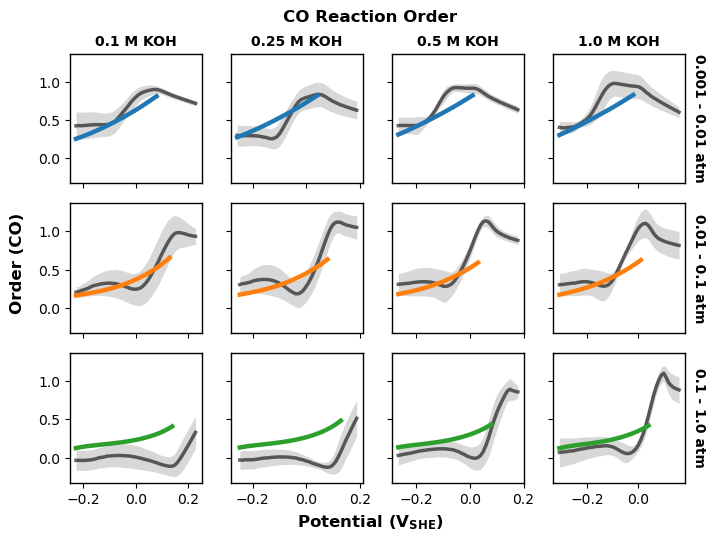

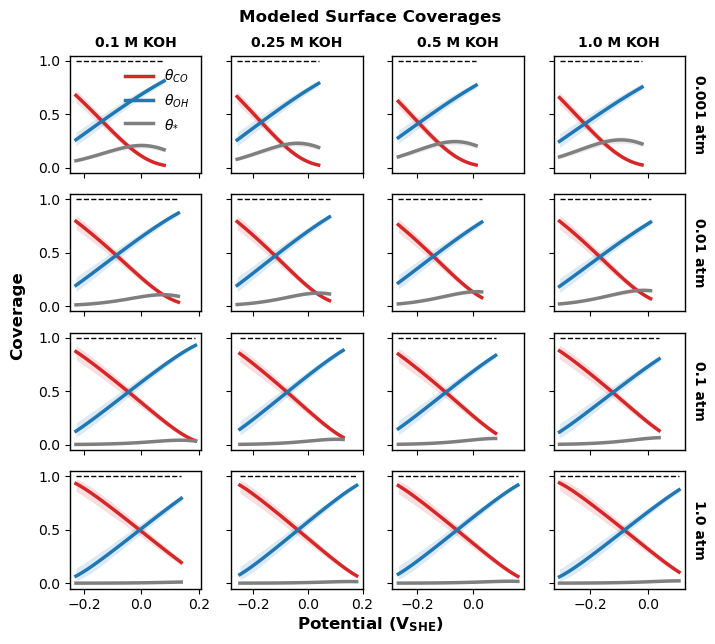

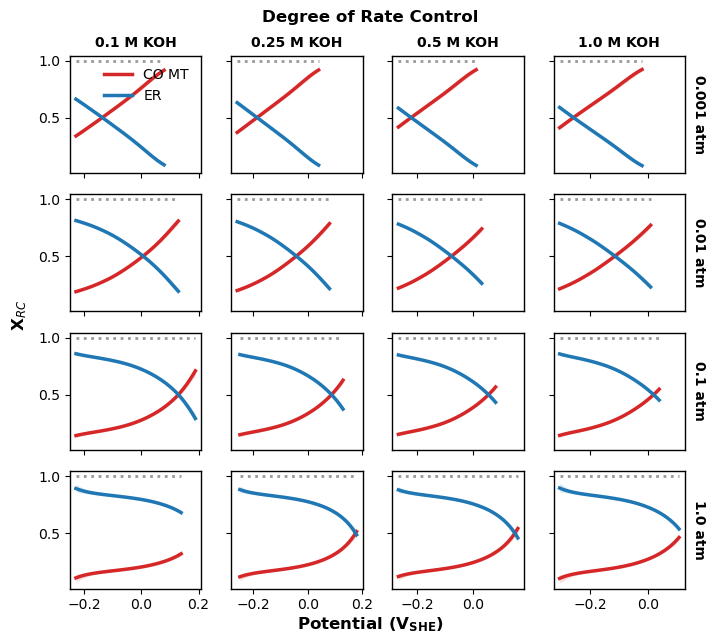

In [26]:
ppc_ER_1_2_lateral_2 = plot_posteriors(trace_ER_1_2_lateral_2, ER_1_2_lateral_2)
plot_model_fits(trace_ER_1_2_lateral_2, ppc_ER_1_2_lateral_2); plot_coverages(trace_ER_1_2_lateral_2)
plot_drc(ER_1_2_lateral_2, trace_ER_1_2_lateral_2, perturb_vars=['delta_BL', 'Gact2_0'], perturb_labels=['CO MT', 'ER'], 
         var_types={'delta_BL': 'resistance', 'Gact2_0': 'Gact'})

# Comparison

                  rank     elpd_loo      p_loo   elpd_diff        weight         se        dse  warning scale
ER_1_2_lateral_2     0  5457.393762  10.297418    0.000000  7.437607e-01  76.983567   0.000000    False   log
ER_1_2_lateral       1  5204.600203   9.734290  252.793559  1.902112e-12  73.139263  32.626806    False   log
ER_1_2               2  5169.740018   8.285809  287.653744  2.562393e-01  72.576027  36.944017    False   log


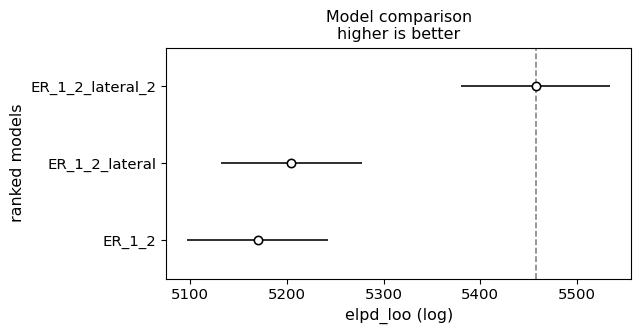

In [27]:
comparison_dict = {
    # "ER_2": loo_ER_2,
    "ER_1_2": loo_ER_1_2,
    # "ER_LH_1_2": loo_ER_LH_1_2,
    # "ER_1_2_kin": loo_ER_1_2_kin,
    'ER_1_2_lateral': loo_ER_1_2_lateral, 
    'ER_1_2_lateral_2': loo_ER_1_2_lateral_2
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()